# Predicting Radical Reaction Rate Constants — Extended Features with SMILES-BERT
## SMILES-BERT · CalcMolDescriptors · Fragments · HOMO/LUMO/Gap · OHE Radical · SHAP

---

**Dataset**: `Clustered.csv` (same content as original xlsx + pre-computed log₁₀(k)) + `Smiles_HOMO_LUMO.csv`  
**Target**: `log₁₀(k_value)` — bimolecular rate constant (L·mol⁻¹·s⁻¹)  
**Radical groups**: `RO2*`, `sec-RO2*`, `tert-RO2*`

**Key features vs Morgan FP notebook**:
- **SMILES-BERT** (ChemBERTa, 768-dim) replaces Morgan fingerprints
- **RDKit CalcMolDescriptors** (~217) + **Fragments** (~85 fr_* functional-group counts)
- **HOMO / LUMO / Gap** retained from GFN2-xTB
- **OHE Radical Name** — one global model, radical type encoded as input
- **StratifiedKFold by radical** — balanced fold proportions, no data leakage
- **SHAP** — interpretable feature importance for best model
- **Per-radical evaluation** + optional **per-radical-group separate models**

### Pipeline
| Step | Description |
|------|-------------|
| 1 | Load data + merge QM descriptors; clean SMILES |
| 2 | EDA — target distribution + per-radical analysis |
| 3 | SMILES-BERT, CalcDesc+Fragments, HOMO/LUMO/Gap, OHE Radical |
| 4 | Benchmark 15 feature representations × DR methods (StratifiedKFold by radical) |
| 5 | Auto-select best representation by CV rank aggregation |
| 6 | Train 7 regressors; compare on held-out test set |
| 7 | Per-radical group evaluation |
| 8 | SHAP feature importance (best model) |
| 9 | Global model vs per-radical-group separate models |
| 10 | Residual analysis |

In [1]:
# Uncomment to install in a fresh environment:
# !pip install rdkit-pypi scikit-learn xgboost lightgbm matplotlib seaborn pandas numpy scipy openpyxl
# !pip install transformers torch   # for SMILES-BERT (ChemBERTa)
# !pip install shap

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.decomposition import PCA, TruncatedSVD, NMF
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ── SMILES-BERT ───────────────────────────────────────────────────────────────
try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    BERT_AVAILABLE = True
    print('transformers + torch available — SMILES-BERT enabled.')
except ImportError:
    BERT_AVAILABLE = False
    print('WARNING: transformers/torch not installed.')
    print('  Install: pip install transformers torch')
    print('  BERT-based feature combinations will be skipped.')

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available.')
except ImportError:
    SHAP_AVAILABLE = False

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('muted')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All libraries loaded.')

transformers + torch available — SMILES-BERT enabled.


SHAP available.
All libraries loaded.


In [3]:
# ─── Global configuration ────────────────────────────────────────────────────
DATA_PATH      = 'Clustered.csv'          # source data (log_k pre-computed, same as original xlsx)
QM_CSV_PATH    = 'Smiles_HOMO_LUMO.csv'
SMILES_COL     = 'SMILES'
RADICAL_COL    = 'Radical Name'
HOMO_COL       = 'HOMO_predicted'
LUMO_COL       = 'LUMO_predicted'
GAP_COL        = 'HOMO_LUMO_gap_predicted'

BERT_MODEL_ID = 'seyonec/ChemBERTa-zinc-base-v1'
BERT_CACHE    = 'bert_embeddings_cache.npy'
BERT_BATCH    = 32

TEST_SIZE  = 0.20
CV_FOLDS   = 5

# ── Feature combination grid ──────────────────────────────────────────────────
# 'ohe' = OHE(Radical Name) — always appended raw after DR
DR_CONFIGS = {
    # ── A. Feature ablation (no DR) ──────────────────────────────────────────
    'BERT+OHE':             {'dr_block': 'bert',             'raw_append': 'ohe',             'method': 'raw', 'n': None},
    'CalcDesc+OHE':         {'dr_block': 'calcdesc',         'raw_append': 'ohe',             'method': 'raw', 'n': None},
    'QM+OHE':               {'dr_block': 'qm',               'raw_append': 'ohe',             'method': 'raw', 'n': None},
    'BERT+QM+OHE':          {'dr_block': 'bert+qm',          'raw_append': 'ohe',             'method': 'raw', 'n': None},
    'BERT+CalcDesc+OHE':    {'dr_block': 'bert+calcdesc',    'raw_append': 'ohe',             'method': 'raw', 'n': None},
    'CalcDesc+QM+OHE':      {'dr_block': 'calcdesc+qm',      'raw_append': 'ohe',             'method': 'raw', 'n': None},
    'All_raw+OHE':          {'dr_block': 'bert+calcdesc+qm', 'raw_append': 'ohe',             'method': 'raw', 'n': None},
    # ── B. DR on BERT only; CalcDesc + QM + OHE appended raw ─────────────────
    'SVD64_BERT+rest+OHE':  {'dr_block': 'bert',             'raw_append': 'calcdesc+qm+ohe', 'method': 'svd', 'n': 64},
    'SVD128_BERT+rest+OHE': {'dr_block': 'bert',             'raw_append': 'calcdesc+qm+ohe', 'method': 'svd', 'n': 128},
    'PCA64_BERT+rest+OHE':  {'dr_block': 'bert',             'raw_append': 'calcdesc+qm+ohe', 'method': 'pca', 'n': 64},
    'PCA128_BERT+rest+OHE': {'dr_block': 'bert',             'raw_append': 'calcdesc+qm+ohe', 'method': 'pca', 'n': 128},
    # ── C. DR on all continuous features; OHE appended raw ───────────────────
    'SVD64_All+OHE':        {'dr_block': 'bert+calcdesc+qm', 'raw_append': 'ohe',             'method': 'svd', 'n': 64},
    'SVD128_All+OHE':       {'dr_block': 'bert+calcdesc+qm', 'raw_append': 'ohe',             'method': 'svd', 'n': 128},
    'PCA64_All+OHE':        {'dr_block': 'bert+calcdesc+qm', 'raw_append': 'ohe',             'method': 'pca', 'n': 64},
    'PCA128_All+OHE':       {'dr_block': 'bert+calcdesc+qm', 'raw_append': 'ohe',             'method': 'pca', 'n': 128},
}

SELECTION_MODELS = {
    'RidgeCV':      RidgeCV(alphas=np.logspace(-3, 3, 13)),
    'RandomForest': RandomForestRegressor(n_estimators=100, min_samples_leaf=2,
                                          random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
}

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def canonicalize(smi):
    if pd.isna(smi):
        return None
    mol = Chem.MolFromSmiles(str(smi).strip())
    return Chem.MolToSmiles(mol) if mol else None

def safe_n(n, X):
    return int(max(2, min(n, X.shape[0] - 1, X.shape[1])))

---
## 1. Data Loading and Cleaning

We load the new xlsx (contains Radical Name and raw k_value) and merge HOMO/LUMO/Gap from the previously computed QM CSV.

In [4]:
# Load source data (Clustered.csv = original xlsx + pre-computed log_k; clusters dropped)
df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.drop(columns=['Mol', 'Cluster'], errors='ignore')

print(f'Data shape  : {df_raw.shape}')
print('Columns     :', df_raw.columns.tolist())
print('\nRadical distribution:')
print(df_raw[RADICAL_COL].value_counts().to_string())
display(df_raw.head(2))

Data shape  : (1213, 13)
Columns     : ['Chemical Name', 'SMILES', 'Radical Name', 'Enthalpy', 'Activation Energy', 'Temperature', 'Bond Dissociation Energy', 'Chemical Group', 'Reaction Type/Pathway', 'PH', 'No', 'Resource:', 'log_k']

Radical distribution:
Radical Name
sec-RO2*     432
RO2*         430
tert-RO2*    345
tert-RO*       2
RO2**          1
HO*            1
sec-RO*        1
Ar-O*          1


,Chemical Name,SMILES,Radical Name,Enthalpy,Activation Energy,Temperature,Bond Dissociation Energy,Chemical Group,Reaction Type/Pathway,PH,No,Resource:,log_k
0,Pentabromoplatinate(III) ion,[Br][Pt+3]([Br])([Br])([Br])[Br],RO2*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,8.39794
1,Copper(I) ion,[Cu+],RO2*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,9.00000


In [5]:
# Load QM descriptors from old CSV (has HOMO/LUMO/Gap computed by GFN2-xTB)
def load_messy_smiles_csv(path):
    """Robust CSV loader: handles chemical names that contain commas."""
    with open(path, 'r', newline='', encoding='utf-8-sig') as f:
        rows = list(csv.reader(f))
    header = rows[0]
    n_tail = len(header) - 1
    fixed = []
    for row in rows[1:]:
        if len(row) < len(header):
            continue
        if len(row) == len(header):
            fixed.append(row)
        else:
            tail = row[-n_tail:]
            name = ','.join(row[:len(row) - n_tail])
            fixed.append([name] + tail)
    return pd.DataFrame(fixed, columns=[header[0]] + header[-n_tail:])

df_qm = load_messy_smiles_csv(QM_CSV_PATH)
for col in [HOMO_COL, LUMO_COL, GAP_COL]:
    df_qm[col] = pd.to_numeric(df_qm[col], errors='coerce')
df_qm['canonical_smiles_qm'] = df_qm[SMILES_COL].apply(canonicalize)

qm_lookup = (
    df_qm.dropna(subset=['canonical_smiles_qm', HOMO_COL, LUMO_COL, GAP_COL])
    .drop_duplicates('canonical_smiles_qm')
    .set_index('canonical_smiles_qm')[[HOMO_COL, LUMO_COL, GAP_COL]]
)
print(f'QM lookup    : {len(qm_lookup)} unique SMILES with HOMO/LUMO/Gap')

QM lookup    : 340 unique SMILES with HOMO/LUMO/Gap


[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'


In [6]:
df = df_raw.copy()
df['log_k'] = pd.to_numeric(df['log_k'], errors='coerce')
df = df.dropna(subset=['log_k', SMILES_COL])
df = df[np.isfinite(df['log_k'])].copy()   # remove -inf / +inf (k_value=0 edge cases)

df['canonical_smiles'] = df[SMILES_COL].apply(canonicalize)

n_before = len(df)
df = df.dropna(subset=['canonical_smiles'])

# Keep only the three significant radical groups
KEEP_RADICALS = {'RO2*', 'sec-RO2*', 'tert-RO2*'}
df = df[df[RADICAL_COL].isin(KEEP_RADICALS)].copy()

# Merge QM descriptors (HOMO/LUMO/Gap from GFN2-xTB)
df = df.join(qm_lookup, on='canonical_smiles', how='left')
df = df.reset_index(drop=True)

qm_ok = df[[HOMO_COL, LUMO_COL, GAP_COL]].notna().all(axis=1).sum()
print(f'Dropped (invalid SMILES / inf log_k / outside 3 radical groups): {n_before - len(df)}')
print(f'Final size      : {len(df)} compounds  ({df["canonical_smiles"].nunique()} unique SMILES)')
print(f'QM available    : {qm_ok}/{len(df)} compounds have HOMO/LUMO/Gap')
print(f'Radical groups  : {df[RADICAL_COL].value_counts().to_dict()}')
display(df[['log_k', HOMO_COL, LUMO_COL, GAP_COL, RADICAL_COL]].describe())

Dropped (invalid SMILES / inf log_k / outside 3 radical groups): 6
Final size      : 1206 compounds  (313 unique SMILES)
QM available    : 1206/1206 compounds have HOMO/LUMO/Gap
Radical groups  : {'sec-RO2*': 432, 'RO2*': 430, 'tert-RO2*': 344}


,log_k,HOMO_predicted,LUMO_predicted,HOMO_LUMO_gap_predicted
count,1206.000000,1206.000000,1206.000000,1206.000000
mean,5.135879,-5.782391,-0.246236,5.536154
std,2.554235,0.581131,1.012644,1.229162
min,-2.000000,-8.299161,-3.652982,1.949052
25%,4.000000,-6.190829,-0.714997,4.890470
50%,5.322219,-5.672629,-0.116957,5.433864
75%,7.079181,-5.393366,0.291552,6.085583
max,9.785330,-4.434598,2.474022,9.090605


---
## 2. Exploratory Data Analysis

### 2.1 Target variable + QM descriptor correlations

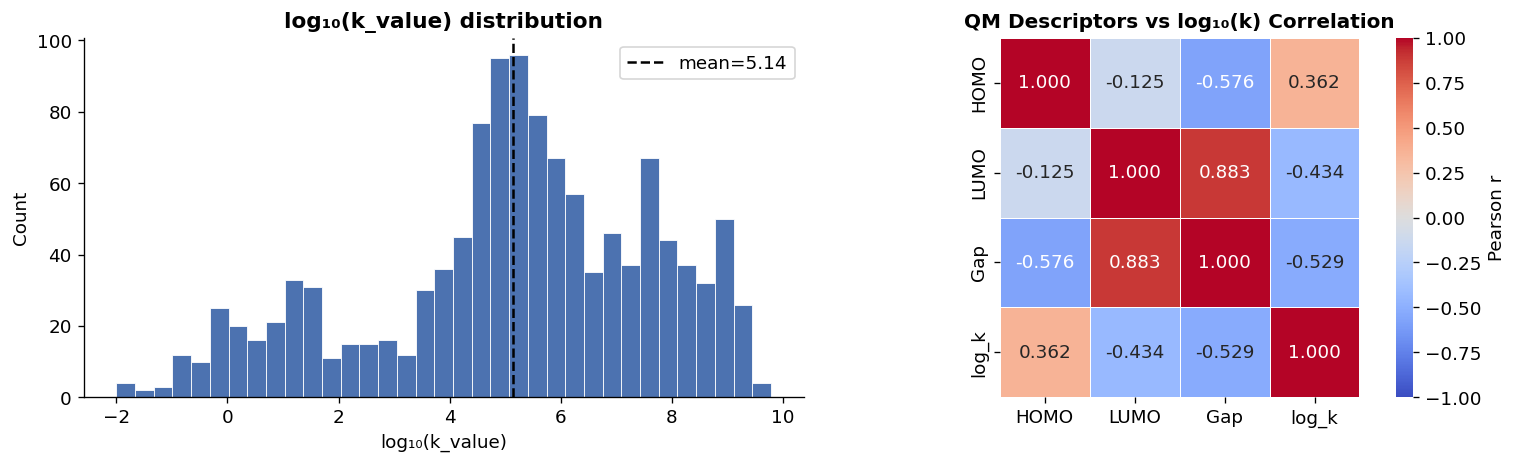

Pearson r with log_k:
  HOMO  : Pearson r = +0.362   Spearman ρ = +0.305
  LUMO  : Pearson r = -0.434   Spearman ρ = -0.381
  Gap   : Pearson r = -0.529   Spearman ρ = -0.469


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['log_k'], bins=35, color='#4C72B0', edgecolor='white', lw=0.5)
axes[0].set_title('log₁₀(k_value) distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log₁₀(k_value)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['log_k'].mean(), color='black', lw=1.5, ls='--',
                label=f"mean={df['log_k'].mean():.2f}")
axes[0].legend()

# Correlation heatmap: QM + log_k
corr_cols = [HOMO_COL, LUMO_COL, GAP_COL, 'log_k']
corr_df = df[corr_cols].dropna().rename(columns={
    HOMO_COL: 'HOMO', LUMO_COL: 'LUMO', GAP_COL: 'Gap', 'log_k': 'log_k'
})
sns.heatmap(corr_df.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
axes[1].set_title('QM Descriptors vs log₁₀(k) Correlation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('Pearson r with log_k:')
for col, label in [(HOMO_COL, 'HOMO'), (LUMO_COL, 'LUMO'), (GAP_COL, 'Gap')]:
    mask = df[col].notna()
    r, _ = pearsonr(df.loc[mask, col], df.loc[mask, 'log_k'])
    rho, _ = spearmanr(df.loc[mask, col], df.loc[mask, 'log_k'])
    print(f'  {label:<6}: Pearson r = {r:+.3f}   Spearman ρ = {rho:+.3f}')

### 2.2 Per-Radical Group Analysis

Distribution of log₁₀(k) across the three kept radical groups. Radical type is encoded as OHE input — one global model is trained on all groups jointly and evaluated per group.

Per-Radical Group Statistics:


,count,mean,std,median,min,max
Radical Name,,,,,,
sec-RO2*,432,5.526,2.506,5.648,-2.000,9.785
RO2*,430,5.767,2.498,5.872,-1.699,9.785
tert-RO2*,344,3.858,2.214,4.312,-1.699,8.301


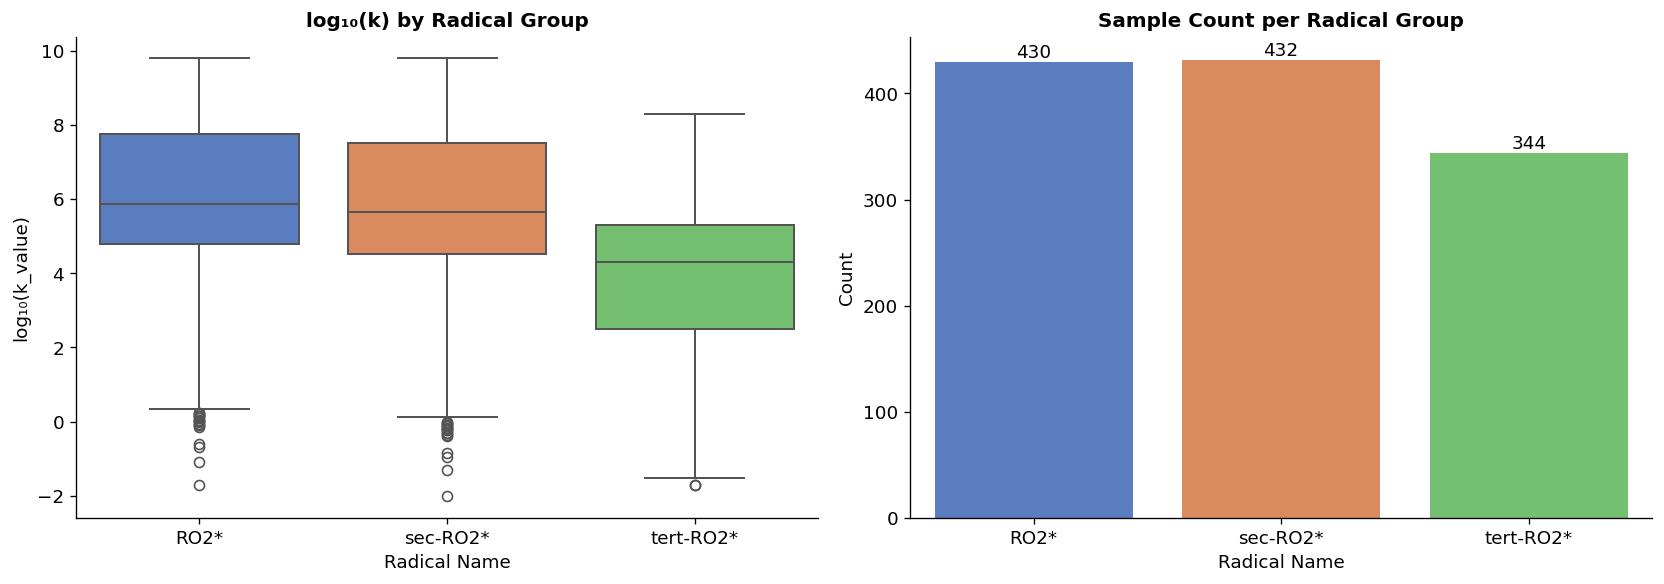

In [8]:
radical_stats = (
    df.groupby(RADICAL_COL)['log_k']
    .agg(count='count', mean='mean', std='std', median='median', min='min', max='max')
    .round(3).sort_values('count', ascending=False)
)
print('Per-Radical Group Statistics:')
display(radical_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df.groupby(RADICAL_COL)['log_k'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x=RADICAL_COL, y='log_k', order=order, ax=axes[0],
            palette='muted', linewidth=1.2)
axes[0].set_title('log₁₀(k) by Radical Group', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Radical Name'); axes[0].set_ylabel('log₁₀(k_value)')

sns.countplot(data=df, x=RADICAL_COL, order=order, ax=axes[1], palette='muted')
axes[1].set_title('Sample Count per Radical Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Radical Name'); axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()

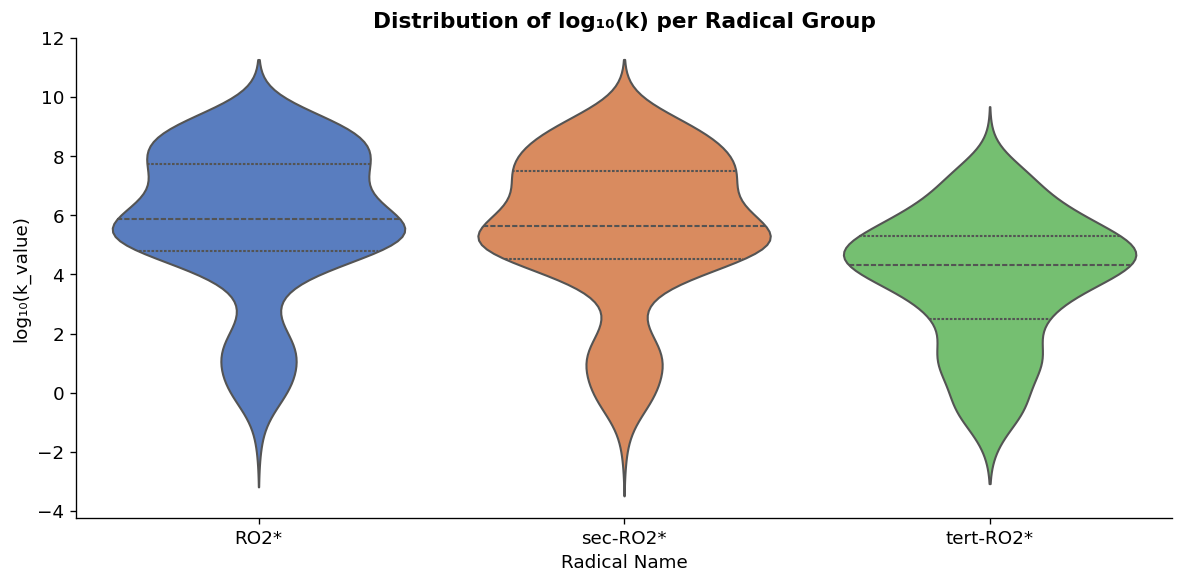

In [9]:
order_v = df.groupby(RADICAL_COL)['log_k'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x=RADICAL_COL, y='log_k', order=order_v,
               inner='quartile', palette='muted', ax=ax)
ax.set_title('Distribution of log₁₀(k) per Radical Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Radical Name'); ax.set_ylabel('log₁₀(k_value)')
plt.tight_layout(); plt.show()

---
## 3. Feature Engineering

| Feature | Dims | Description |
|---|---|---|
| **SMILES-BERT** (ChemBERTa) | 768 | Contextual SMILES embeddings (replaces Morgan FP) |
| **CalcMolDescriptors** | ~217 | MW, LogP, TPSA, HBD/HBA, ring counts, … |
| **Fragments (fr_*)** | ~85 | Functional-group counts (fr_NH0, fr_Ar_OH, fr_ester, …) |
| **HOMO / LUMO / Gap** | 3 | GFN2-xTB semiempirical DFT |
| **OHE Radical Name** | n_rad−1 | Mechanism-level reactivity bias (always appended raw) |

In [10]:
# Build working dataset with only valid RDKit mols
valid_idx = []
for i, smi in enumerate(df['canonical_smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        valid_idx.append(i)

df_model = df.iloc[valid_idx].reset_index(drop=True).copy()
y_all     = df_model['log_k'].values
smiles_all = df_model['canonical_smiles'].tolist()
print(f'Working dataset: {len(df_model)} compounds')

Working dataset: 1206 compounds


In [11]:
# ── 3.1 SMILES-BERT (ChemBERTa) ────────────────────────────────────────────
# CLS-token embedding from seyonec/ChemBERTa-zinc-base-v1 (768-dim).
# Embeddings are cached to disk; cache is auto-invalidated if molecule count changes.

if BERT_AVAILABLE:
    X_bert = None
    if os.path.exists(BERT_CACHE):
        _cached = np.load(BERT_CACHE)
        if _cached.shape[0] == len(smiles_all):
            X_bert = _cached
            print(f'Loaded BERT embeddings from cache: {X_bert.shape}')
        else:
            print(f'Cache size mismatch ({_cached.shape[0]} cached vs {len(smiles_all)} needed) — recomputing.')

    if X_bert is None:
        print(f'Downloading & running ChemBERTa: {BERT_MODEL_ID}')
        tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
        bert_model = AutoModel.from_pretrained(BERT_MODEL_ID)
        bert_model.eval()
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        bert_model = bert_model.to(device)
        print(f'  Device: {device}  |  {len(smiles_all)} molecules')

        emb_list = []
        with torch.no_grad():
            for i in range(0, len(smiles_all), BERT_BATCH):
                batch = smiles_all[i:i + BERT_BATCH]
                encoded = tokenizer(batch, padding=True, truncation=True,
                                    max_length=512, return_tensors='pt')
                encoded = {k: v.to(device) for k, v in encoded.items()}
                cls_emb = bert_model(**encoded).last_hidden_state[:, 0, :].cpu().numpy()
                emb_list.append(cls_emb)
                if (i // BERT_BATCH) % 10 == 0:
                    print(f'  {min(i+BERT_BATCH, len(smiles_all))}/{len(smiles_all)}', flush=True)

        X_bert = np.vstack(emb_list).astype(np.float32)
        np.save(BERT_CACHE, X_bert)
        print(f'  Saved to {BERT_CACHE}')

    print(f'SMILES-BERT shape : {X_bert.shape}')
else:
    X_bert = None
    print('BERT not available — BERT-based configs will be skipped.')

Loaded BERT embeddings from cache: (1206, 768)
SMILES-BERT shape : (1206, 768)


In [12]:
# ── 3.2 RDKit CalcMolDescriptors + Fragments ───────────────────────────────
# CalcMolDescriptors: ~217 physicochemical descriptors (MW, LogP, TPSA, …)
# Fragments: ~85 fr_* functional-group counts (fr_NH0, fr_Ar_OH, fr_ester, …)
from rdkit.Chem import Fragments as RDKitFrags

print('Computing RDKit CalcMolDescriptors + Fragments...', flush=True)
desc_rows, frag_rows = [], []
desc_names, frag_names = None, None

# Collect fragment function names once
_frag_names_all = sorted([name for name in dir(RDKitFrags)
                           if name.startswith('fr_') and callable(getattr(RDKitFrags, name))])

for smi in smiles_all:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        d = Descriptors.CalcMolDescriptors(mol)
        if desc_names is None:
            desc_names = list(d.keys())
        desc_rows.append(list(d.values()))

        frag_vals = [getattr(RDKitFrags, fn)(mol) for fn in _frag_names_all]
        frag_rows.append(frag_vals)
    else:
        n_d = len(desc_names) if desc_names else 1
        desc_rows.append([np.nan] * n_d)
        frag_rows.append([np.nan] * len(_frag_names_all))

if frag_names is None:
    frag_names = _frag_names_all

# Combine descriptors + fragments
X_desc_raw = np.array(desc_rows, dtype=np.float64)
X_frag_raw = np.array(frag_rows, dtype=np.float64)
X_combined  = np.hstack([X_desc_raw, X_frag_raw])
X_combined  = np.where(np.isinf(X_combined), np.nan, X_combined)

all_feat_names = (desc_names or []) + frag_names
col_mask = (~np.all(np.isnan(X_combined), axis=0)) & (np.nanstd(X_combined, axis=0) > 0)
X_combined = X_combined[:, col_mask]
calcdesc_names_kept = [n for n, m in zip(all_feat_names, col_mask) if m]

imputer   = SimpleImputer(strategy='median')
X_calcdesc = imputer.fit_transform(X_combined).astype(np.float32)

print(f'CalcMolDescriptors : {len(desc_names or [])} features')
print(f'Fragments (fr_*)   : {len(frag_names)} features')
print(f'Combined shape     : {X_calcdesc.shape}  (after removing constants/all-NaN cols)')

Computing RDKit CalcMolDescriptors + Fragments...


CalcMolDescriptors : 217 features
Fragments (fr_*)   : 85 features
Combined shape     : (1206, 252)  (after removing constants/all-NaN cols)


In [13]:
# ── 3.3 HOMO / LUMO / HOMO-LUMO Gap ───────────────────────────────────────
qm_raw  = df_model[[HOMO_COL, LUMO_COL, GAP_COL]].values.astype(np.float32)
# Impute any missing with median (very few expected)
qm_imp  = SimpleImputer(strategy='median')
X_qm    = qm_imp.fit_transform(qm_raw)

print(f'QM descriptors shape : {X_qm.shape}')
print(f'  Missing before imputation: {np.isnan(qm_raw).sum()} values')

QM descriptors shape : (1206, 3)
  Missing before imputation: 0 values


In [14]:
# ── 3.4 One-Hot Encoding: Radical Name ───────────────────────────────────────
# OHE(Radical Name) is always appended raw — never compressed by DR.
ohe_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
X_ohe   = ohe_enc.fit_transform(df_model[[RADICAL_COL]])

radical_cats = ohe_enc.categories_[0].tolist()
print(f'OHE Radical : {X_ohe.shape}  (categories: {radical_cats})')
print(f'\n--- Feature summary ---')
print(f'SMILES-BERT       : {X_bert.shape if X_bert is not None else "N/A"}')
print(f'CalcDesc+Fragments: {X_calcdesc.shape}')
print(f'HOMO/LUMO/Gap     : {X_qm.shape}')
print(f'OHE Radical       : {X_ohe.shape}')

OHE Radical : (1206, 2)  (categories: ['RO2*', 'sec-RO2*', 'tert-RO2*'])

--- Feature summary ---
SMILES-BERT       : (1206, 768)
CalcDesc+Fragments: (1206, 252)
HOMO/LUMO/Gap     : (1206, 3)
OHE Radical       : (1206, 2)


---
## 4. Train / Test Split (Stratified by Radical Group)

80/20 stratified split — radical group proportions are preserved in both sets.  
`StratifiedKFold` by radical group is used in CV to prevent fold imbalance.  
All scalers and DR transformers are fitted **only on the training set** to prevent data leakage.

In [15]:
from sklearn.model_selection import StratifiedKFold

indices     = np.arange(len(y_all))
radical_all = df_model[RADICAL_COL].values

# Stratify by radical group — ensures each fold sees all 3 groups proportionally
idx_tr, idx_te = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=radical_all
)

y_train, y_test = y_all[idx_tr], y_all[idx_te]
strat_tr = radical_all[idx_tr]   # radical labels used for StratifiedKFold in CV

X_bert_tr     = X_bert[idx_tr]     if X_bert is not None else None
X_bert_te     = X_bert[idx_te]     if X_bert is not None else None
X_calcdesc_tr = X_calcdesc[idx_tr]
X_calcdesc_te = X_calcdesc[idx_te]
X_qm_tr       = X_qm[idx_tr]
X_qm_te       = X_qm[idx_te]
X_ohe_tr      = X_ohe[idx_tr]
X_ohe_te      = X_ohe[idx_te]

# Scale continuous features on TRAIN ONLY — prevents data leakage
sc_bert = StandardScaler()
sc_calc = StandardScaler()
sc_qm   = StandardScaler()

X_bert_tr_s     = sc_bert.fit_transform(X_bert_tr)    if X_bert_tr is not None else None
X_bert_te_s     = sc_bert.transform(X_bert_te)        if X_bert_te is not None else None
X_calcdesc_tr_s = sc_calc.fit_transform(X_calcdesc_tr)
X_calcdesc_te_s = sc_calc.transform(X_calcdesc_te)
X_qm_tr_s       = sc_qm.fit_transform(X_qm_tr)
X_qm_te_s       = sc_qm.transform(X_qm_te)

print(f'Training : {len(y_train)} compounds  |  Test : {len(y_test)} compounds')
print(f'Stratified by radical group')
print(f'Train: {pd.Series(strat_tr).value_counts().to_dict()}')
print(f'Test : {pd.Series(radical_all[idx_te]).value_counts().to_dict()}')
print(f'log_k train : [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'log_k test  : [{y_test.min():.2f}, {y_test.max():.2f}]')

Training : 964 compounds  |  Test : 242 compounds
Stratified by radical group
Train: {'sec-RO2*': 345, 'RO2*': 344, 'tert-RO2*': 275}
Test : {'sec-RO2*': 87, 'RO2*': 86, 'tert-RO2*': 69}
log_k train : [-2.00, 9.79]
log_k test  : [-1.40, 9.79]


---
## 5. Dimensionality Reduction Benchmark — 15 Feature Combinations

Three groups of configurations, answering different questions:

| Group | Question | Configs |
|-------|----------|---------|
| **A. Ablation (no DR)** | Which features contribute? | 7 raw combos |
| **B. DR on BERT only** | Does compressing BERT (768→64/128) help, keeping CalcDesc+QM raw? | 4 configs |
| **C. DR on all features** | Does joint compression of all 988 dims help? | 4 configs |

**OHE Radical is always appended raw after DR** — it's binary and low-dimensional (7 cols).

```
Group B example (SVD128_BERT+rest+OHE):
  BERT (768) ──► SVD(128) ──┐
  CalcDesc (217) ────────────┼── hstack ──► 128+217+3+7 = 355 dims
  QM (3) ────────────────────┤
  OHE (7) ───────────────────┘

Group C example (SVD128_All+OHE):
  BERT (768) ─┐
  CalcDesc────┼── hstack (988) ──► SVD(128) ──┐
  QM (3) ─────┘                                ├── hstack ──► 128+7 = 135 dims
  OHE (7) ─────────────────────────────────────┘
```

**Selection**: rank by 5-fold CV RMSE across 3 benchmark models → pick by average rank.

In [16]:
def apply_dr(Xtr, Xte, method, n):
    """Fit DR on training set only; return (Xtr_red, Xte_red, meta)."""
    if method == 'raw':
        return Xtr.copy(), Xte.copy(), {'n_features': Xtr.shape[1]}
    if method == 'svd':
        k = safe_n(n, Xtr)
        red = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
        ev  = float(red.fit(Xtr).explained_variance_ratio_.sum())
        return red.transform(Xtr), red.transform(Xte), {'k': k, 'expl_var': ev}
    if method == 'pca':
        sc  = StandardScaler()
        Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
        k = safe_n(n, Xtr_s)
        red = PCA(n_components=k, random_state=RANDOM_STATE)
        ev  = float(red.fit(Xtr_s).explained_variance_ratio_.sum())
        return red.transform(Xtr_s), red.transform(Xte_s), {'k': k, 'expl_var': ev}
    raise ValueError(f'Unknown DR method: {method}')


# Lookup table: token → (train_array, test_array)
FEAT_LOOKUP = {
    'bert':     (X_bert_tr_s,     X_bert_te_s),
    'calcdesc': (X_calcdesc_tr_s, X_calcdesc_te_s),
    'qm':       (X_qm_tr_s,       X_qm_te_s),
    'ohe':      (X_ohe_tr,        X_ohe_te),
}

def parse_block(tag):
    """Return (Xtr, Xte) by hstacking named tokens from tag string (e.g. 'bert+calcdesc+qm')."""
    tokens = [t.strip() for t in tag.split('+') if t.strip()]
    tr_parts, te_parts = [], []
    for t in tokens:
        if t not in FEAT_LOOKUP:
            raise ValueError(f'Unknown feature token: {t!r}')
        arr_tr, arr_te = FEAT_LOOKUP[t]
        if arr_tr is None:
            return None, None   # BERT unavailable
        tr_parts.append(arr_tr)
        te_parts.append(arr_te)
    return np.hstack(tr_parts).astype(np.float32), np.hstack(te_parts).astype(np.float32)


feature_sets = {}

print(f'{"Name":<28} {"DR":<8} {"DR block dims":<16} {"Final train shape":<20} Notes')
print('-' * 88)

for name, cfg in DR_CONFIGS.items():
    method = cfg['method']
    n_comp = cfg['n']

    # 1. Build the block that goes into DR
    Xdr_tr, Xdr_te = parse_block(cfg['dr_block'])
    if Xdr_tr is None:
        print(f'{name:<28} SKIPPED (BERT unavailable)')
        continue

    # 2. Apply DR
    Xred_tr, Xred_te, meta = apply_dr(Xdr_tr, Xdr_te, method, n_comp)

    # 3. Build the block appended raw after DR
    raw_tag = cfg['raw_append']
    if raw_tag:
        Xraw_tr, Xraw_te = parse_block(raw_tag)
        Xtr_final = np.hstack([Xred_tr, Xraw_tr]).astype(np.float32)
        Xte_final = np.hstack([Xred_te, Xraw_te]).astype(np.float32)
    else:
        Xtr_final = Xred_tr.astype(np.float32)
        Xte_final = Xred_te.astype(np.float32)

    feature_sets[name] = {'Xtr': Xtr_final, 'Xte': Xte_final, 'meta': meta, 'cfg': cfg}

    note = f'expl_var={meta["expl_var"]:.3f}' if 'expl_var' in meta else ''
    print(f'{name:<28} {method:<8} {str(Xdr_tr.shape[1])+"→"+str(Xred_tr.shape[1]):<16} '
          f'{str(Xtr_final.shape):<20} {note}')

print(f'\n{len(feature_sets)} feature combinations built without data leakage ✓')

Name                         DR       DR block dims    Final train shape    Notes
----------------------------------------------------------------------------------------
BERT+OHE                     raw      768→768          (964, 770)           
CalcDesc+OHE                 raw      252→252          (964, 254)           
QM+OHE                       raw      3→3              (964, 5)             
BERT+QM+OHE                  raw      771→771          (964, 773)           


BERT+CalcDesc+OHE            raw      1020→1020        (964, 1022)          


CalcDesc+QM+OHE              raw      255→255          (964, 257)           
All_raw+OHE                  raw      1023→1023        (964, 1025)          


SVD64_BERT+rest+OHE          svd      768→64           (964, 321)           expl_var=0.944


SVD128_BERT+rest+OHE         svd      768→128          (964, 385)           expl_var=0.988
PCA64_BERT+rest+OHE          pca      768→64           (964, 321)           expl_var=0.944


PCA128_BERT+rest+OHE         pca      768→128          (964, 385)           expl_var=0.988
SVD64_All+OHE                svd      1023→64          (964, 66)            expl_var=0.909


SVD128_All+OHE               svd      1023→128         (964, 130)           expl_var=0.980
PCA64_All+OHE                pca      1023→64          (964, 66)            expl_var=0.909


PCA128_All+OHE               pca      1023→128         (964, 130)           expl_var=0.980

15 feature combinations built without data leakage ✓


---
## 6. Automatic Representation Selection — Cross-Validation Benchmark

Same protocol as previous notebook: rank each representation within each benchmark model by CV RMSE, select by average rank.

In [17]:
# StratifiedKFold by radical group — balanced representation in each fold
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(skf.split(np.zeros(len(y_train)), strat_tr))

SCALE_FOR_BENCH = {'RidgeCV'}

bench_rows = []
print(f'{"Representation":<30} {"Model":<14} {"CV RMSE":>9}  ±{"STD":>6}')
print('-' * 66)

for fname, fs in feature_sets.items():
    for mname, model in SELECTION_MODELS.items():
        Xtr = fs['Xtr']
        if mname in SCALE_FOR_BENCH:
            Xtr = StandardScaler().fit_transform(Xtr)
        scores = cross_val_score(model, Xtr, y_train,
                                 scoring='neg_root_mean_squared_error',
                                 cv=cv_splits, n_jobs=1)
        mean_cv = float(-scores.mean())
        std_cv  = float(scores.std())
        bench_rows.append({'Representation': fname, 'Model': mname,
                           'CV_RMSE': mean_cv, 'CV_STD': std_cv})
        print(f'{fname:<30} {mname:<14} {mean_cv:9.4f}  ±{std_cv:6.4f}')

bench_df = pd.DataFrame(bench_rows)
print('\nBenchmark complete.')

Representation                 Model            CV RMSE  ±   STD
------------------------------------------------------------------


BERT+OHE                       RidgeCV           1.2773  ±0.0962


BERT+OHE                       RandomForest      1.2407  ±0.1210


BERT+OHE                       XGBoost           1.1809  ±0.1025


CalcDesc+OHE                   RidgeCV           1.4275  ±0.0969


...

PCA64_All+OHE                  RandomForest      1.2473  ±0.1715


PCA64_All+OHE                  XGBoost           1.1654  ±0.1183


PCA128_All+OHE                 RidgeCV           1.4136  ±0.0986


PCA128_All+OHE                 RandomForest      1.2581  ±0.1733


PCA128_All+OHE                 XGBoost           1.1900  ±0.1337

Benchmark complete.


In [18]:
bench_df['Rank'] = bench_df.groupby('Model')['CV_RMSE'].rank(method='average')

summary_df = (
    bench_df.groupby('Representation', as_index=False)
    .agg(Mean_CV_RMSE=('CV_RMSE', 'mean'),
         Std_CV_RMSE=('CV_RMSE', 'std'),
         Mean_Rank=('Rank', 'mean'),
         Best_CV_RMSE=('CV_RMSE', 'min'))
    .sort_values('Mean_Rank')
    .reset_index(drop=True)
)

BEST_REPR = summary_df.loc[0, 'Representation']
print(f'Selected best representation: {BEST_REPR}\n')
display(summary_df.style
    .background_gradient(subset=['Mean_CV_RMSE', 'Mean_Rank'], cmap='RdYlGn_r')
    .format({'Mean_CV_RMSE': '{:.4f}', 'Std_CV_RMSE': '{:.4f}',
             'Mean_Rank': '{:.2f}', 'Best_CV_RMSE': '{:.4f}'}))

Selected best representation: SVD64_BERT+rest+OHE



,Representation,Mean_CV_RMSE,Std_CV_RMSE,Mean_Rank,Best_CV_RMSE
0,SVD64_BERT+rest+OHE,1.1828,0.0920,4.00,1.1027
1,CalcDesc+QM+OHE,1.2075,0.1675,4.33,1.0850
2,PCA64_BERT+rest+OHE,1.1847,0.0904,4.67,1.1101
3,CalcDesc+OHE,1.2136,0.1871,4.67,1.0808
4,All_raw+OHE,1.1827,0.0590,5.00,1.1274
5,PCA128_BERT+rest+OHE,1.1960,0.1064,5.67,1.1077
6,BERT+CalcDesc+OHE,1.1876,0.0556,6.00,1.1388
7,SVD128_BERT+rest+OHE,1.1979,0.1042,6.33,1.1147
8,BERT+OHE,1.2330,0.0487,8.33,1.1809
9,BERT+QM+OHE,1.2268,0.0334,8.67,1.1908


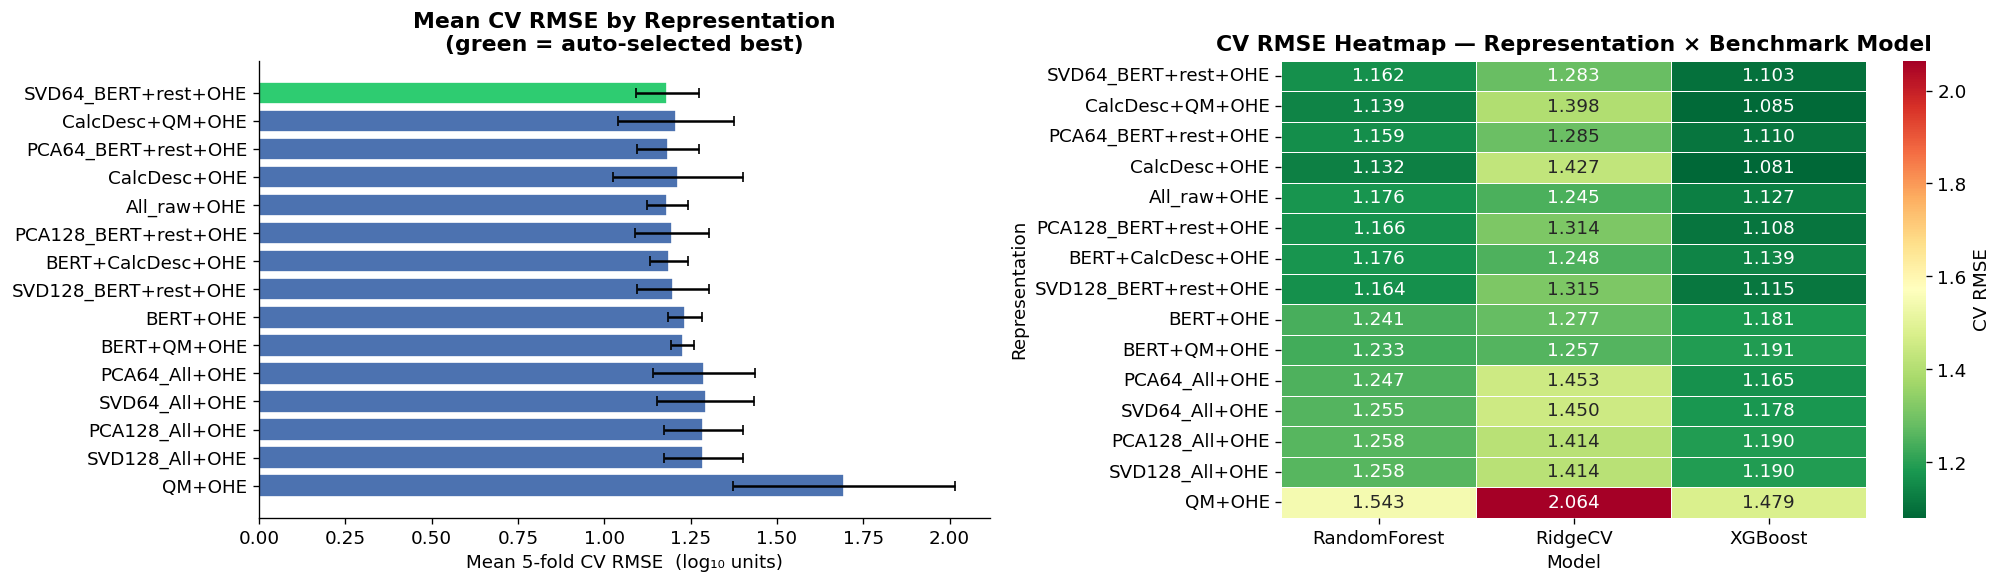

Best: "SVD64_BERT+rest+OHE" ranks best on average across all three benchmark models.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

bar_c = ['#2ecc71' if r == BEST_REPR else '#4C72B0' for r in summary_df['Representation']]
axes[0].barh(summary_df['Representation'], summary_df['Mean_CV_RMSE'],
             xerr=summary_df['Std_CV_RMSE'], color=bar_c, edgecolor='white', capsize=3)
axes[0].set_xlabel('Mean 5-fold CV RMSE  (log₁₀ units)', fontsize=11)
axes[0].set_title('Mean CV RMSE by Representation\n(green = auto-selected best)', fontweight='bold')
axes[0].invert_yaxis()

pivot = (bench_df.pivot(index='Representation', columns='Model', values='CV_RMSE')
         .loc[summary_df['Representation']])
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'CV RMSE'})
axes[1].set_title('CV RMSE Heatmap — Representation × Benchmark Model', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Best: "{BEST_REPR}" ranks best on average across all three benchmark models.')

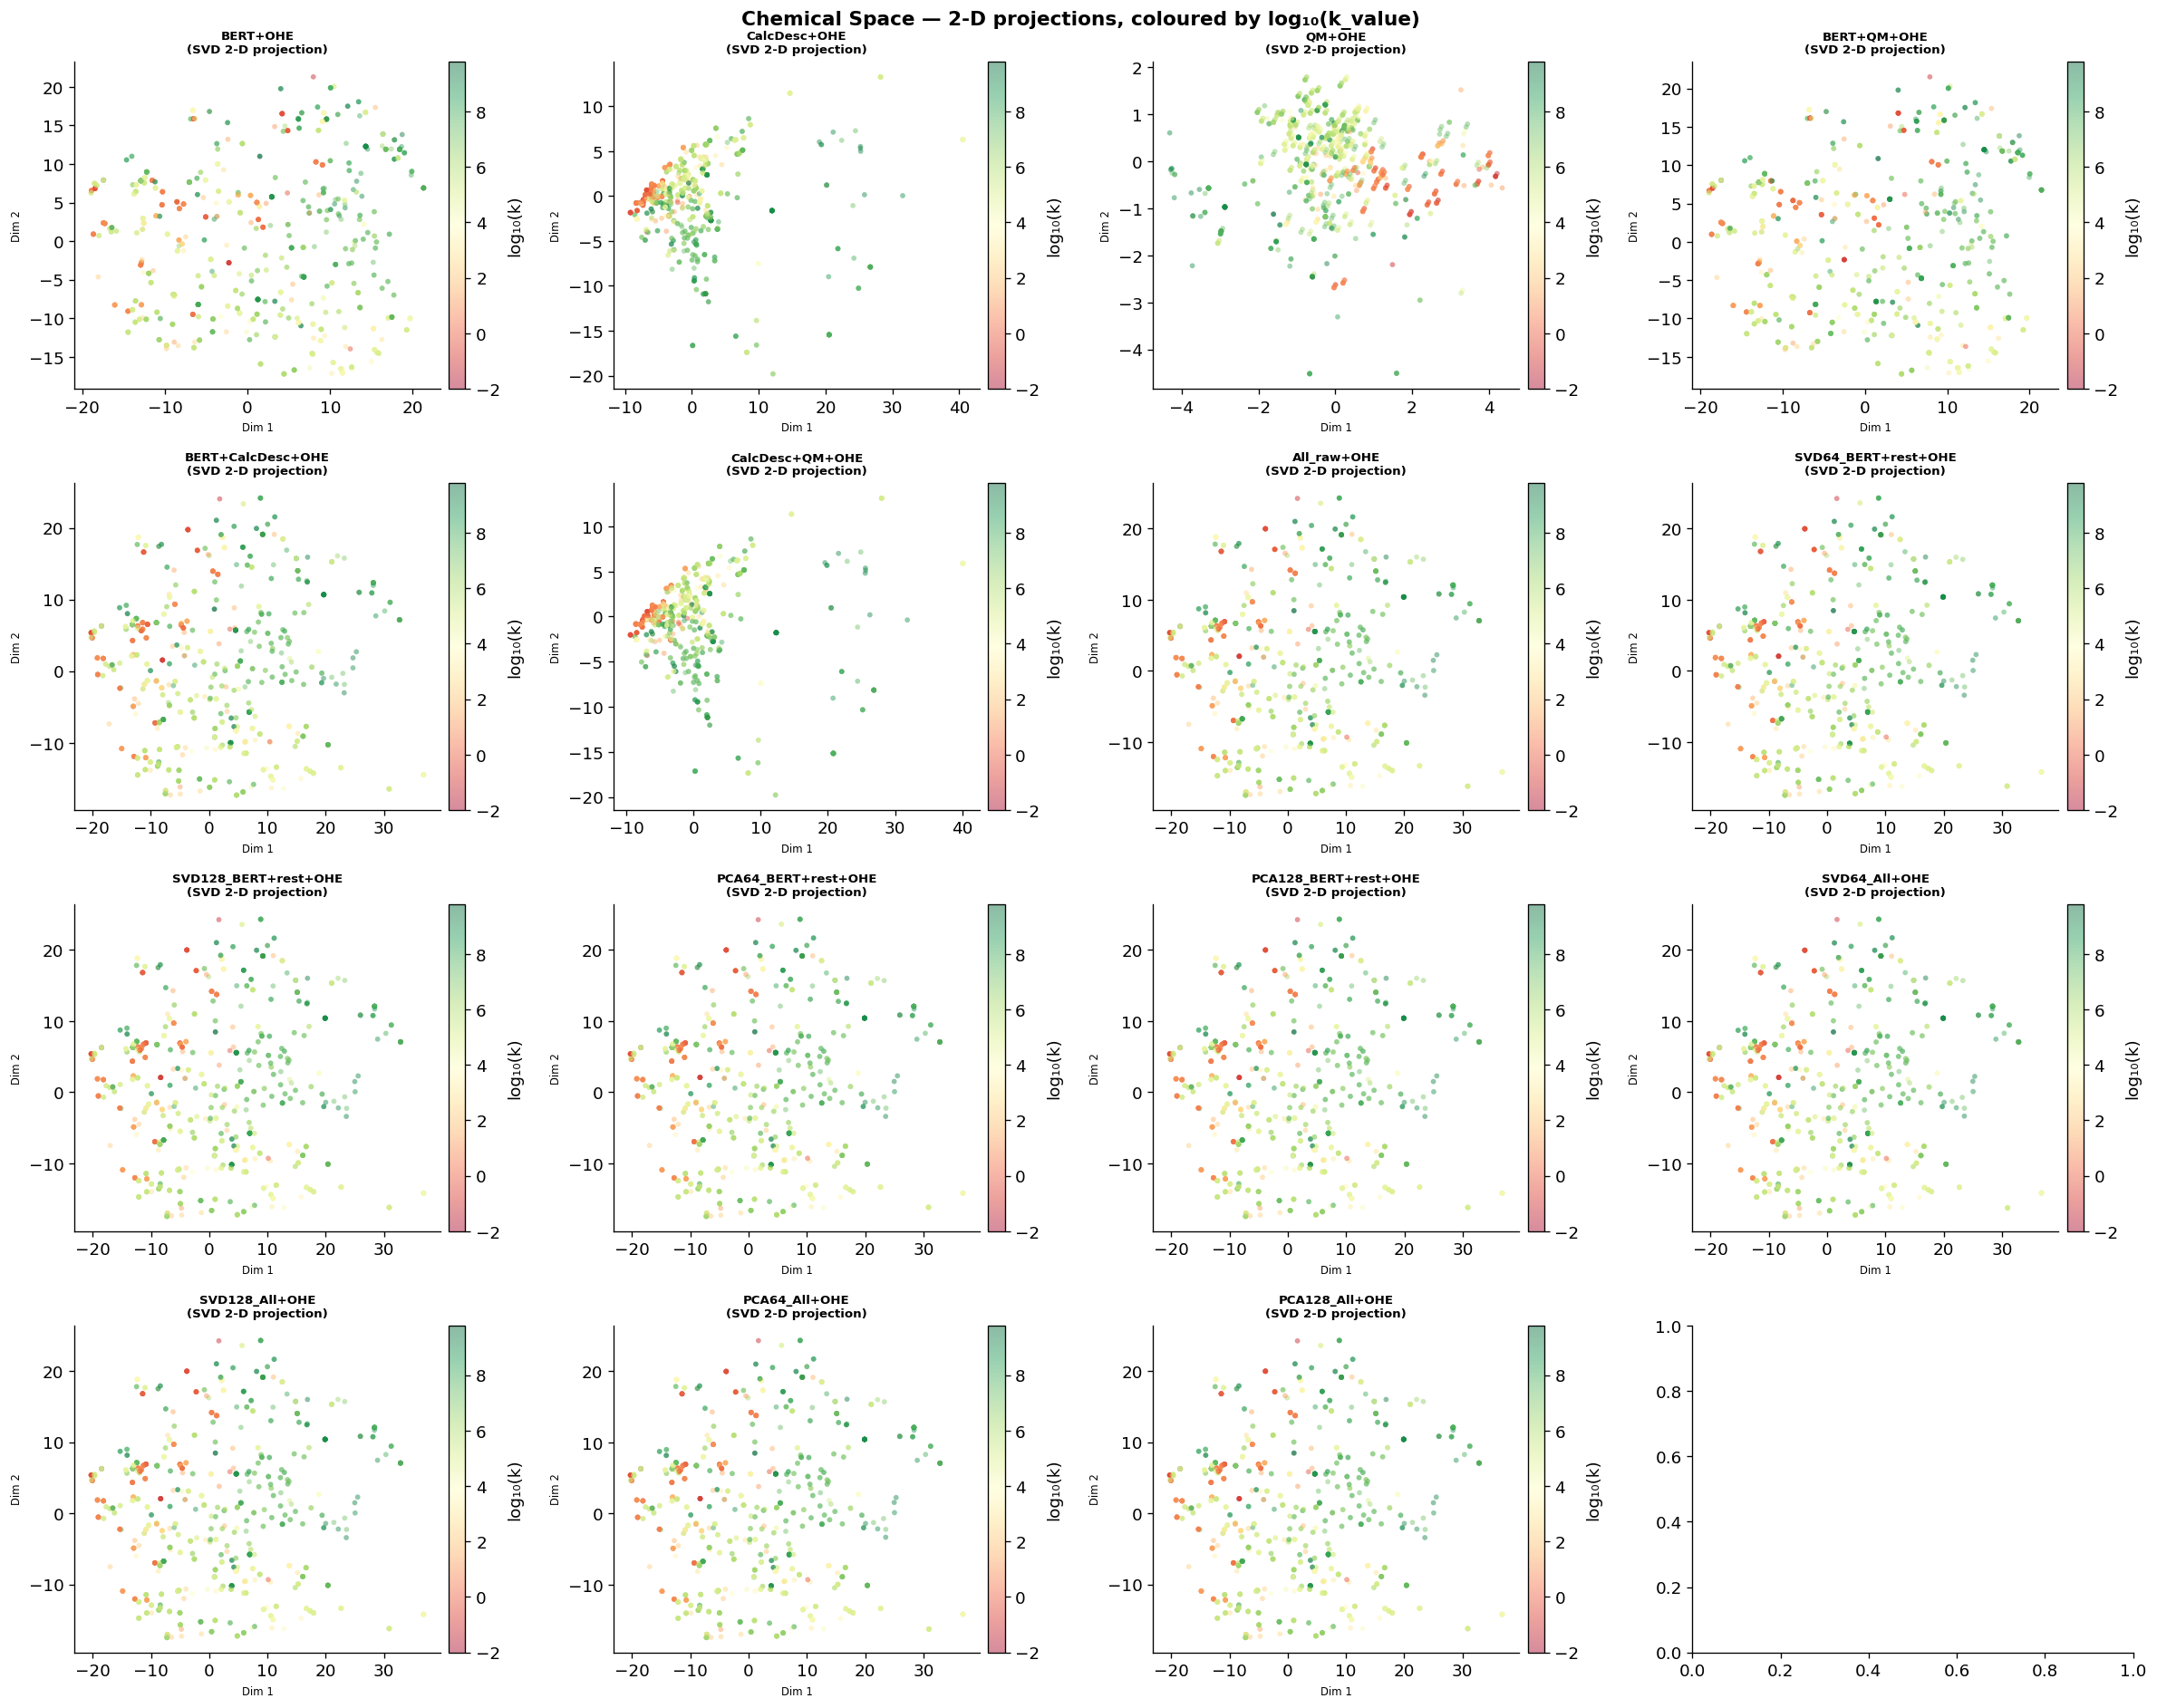

In [20]:
# 2-D chemical space visualisation (all representations)
y_combined = np.concatenate([y_train, y_test])
n_plots = len(feature_sets)
ncols = 4
nrows = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flat

vmin, vmax = y_combined.min(), y_combined.max()
for ax, (name, fs) in zip(axes, feature_sets.items()):
    Xall = np.vstack([fs['Xtr'], fs['Xte']])
    if Xall.shape[1] >= 2:
        coords = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(Xall)
        title  = f'{name}\n(SVD 2-D projection)'
    else:
        coords = np.column_stack([Xall[:, 0], np.zeros(len(Xall))])
        title  = name
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=y_combined, cmap='RdYlGn',
                    vmin=vmin, vmax=vmax, alpha=0.45, s=12, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='log₁₀(k)', pad=0.02)
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.set_xlabel('Dim 1', fontsize=7); ax.set_ylabel('Dim 2', fontsize=7)

for ax in list(axes)[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Chemical Space — 2-D projections, coloured by log₁₀(k_value)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Final Modeling on the Selected Representation

In [21]:
FINAL_MODELS = {
    'Ridge':         RidgeCV(alphas=np.logspace(-3, 3, 13)),
    'LassoCV':       LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000),
    'SVR (RBF)':     SVR(C=10, epsilon=0.1, kernel='rbf'),
    'KNN':           KNeighborsRegressor(n_neighbors=7, weights='distance'),
    'RandomForest':  RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                           random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':       XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6,
                                  subsample=0.8, colsample_bytree=0.8,
                                  reg_alpha=0.1, reg_lambda=1.0,
                                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM':      LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
}
SCALE_NEEDED = {'Ridge', 'LassoCV', 'SVR (RBF)', 'KNN'}

Xtr_active = feature_sets[BEST_REPR]['Xtr']
Xte_active = feature_sets[BEST_REPR]['Xte']

sc_final   = StandardScaler()
Xtr_scaled = sc_final.fit_transform(Xtr_active)
Xte_scaled = sc_final.transform(Xte_active)

results, fitted_models = [], {}

for mname, model in FINAL_MODELS.items():
    Xtr_use = Xtr_scaled if mname in SCALE_NEEDED else Xtr_active
    Xte_use = Xte_scaled if mname in SCALE_NEEDED else Xte_active
    m = clone(model)
    m.fit(Xtr_use, y_train)
    ptr = m.predict(Xtr_use)
    pte = m.predict(Xte_use)
    results.append({'Model': mname,
                    'Train RMSE': rmse(y_train, ptr), 'Test RMSE': rmse(y_test, pte),
                    'Train MAE':  mean_absolute_error(y_train, ptr),
                    'Test MAE':   mean_absolute_error(y_test, pte),
                    'Train R²':   r2_score(y_train, ptr),
                    'Test R²':    r2_score(y_test, pte),
                    'Feature Set': BEST_REPR})
    fitted_models[mname] = (m, mname in SCALE_NEEDED)
    print(f'{mname:<16}: Test RMSE={rmse(y_test,pte):.4f}  R²={r2_score(y_test,pte):.4f}')

results_df = pd.DataFrame(results).sort_values('Test RMSE').reset_index(drop=True)
print(f'\nFeature set : {BEST_REPR}')
print(f'Train size  : {Xtr_active.shape[0]}   Test size : {Xte_active.shape[0]}')

Ridge           : Test RMSE=1.3541  R²=0.7171


LassoCV         : Test RMSE=1.3214  R²=0.7306


SVR (RBF)       : Test RMSE=0.8884  R²=0.8782


KNN             : Test RMSE=1.1935  R²=0.7803


RandomForest    : Test RMSE=0.9120  R²=0.8717


XGBoost         : Test RMSE=0.8893  R²=0.8780


LightGBM        : Test RMSE=0.9031  R²=0.8742

Feature set : SVD64_BERT+rest+OHE
Train size  : 964   Test size : 242


In [22]:
display(
    results_df.style
    .background_gradient(subset=['Test RMSE', 'Train RMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Test R²',   'Train R²'],   cmap='RdYlGn')
    .format({c: '{:.4f}' for c in
             ['Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R²', 'Test R²']})
)

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²,Feature Set
0,SVR (RBF),0.7450,0.8884,0.4165,0.6135,0.9150,0.8782,SVD64_BERT+rest+OHE
1,XGBoost,0.5229,0.8893,0.3394,0.6128,0.9581,0.8780,SVD64_BERT+rest+OHE
2,LightGBM,0.5596,0.9031,0.3588,0.6499,0.9520,0.8742,SVD64_BERT+rest+OHE
3,RandomForest,0.6319,0.9120,0.4289,0.6547,0.9388,0.8717,SVD64_BERT+rest+OHE
4,KNN,0.4792,1.1935,0.2417,0.8723,0.9648,0.7803,SVD64_BERT+rest+OHE
5,LassoCV,1.0310,1.3214,0.7529,0.9114,0.8372,0.7306,SVD64_BERT+rest+OHE
6,Ridge,0.9779,1.3541,0.7089,0.9024,0.8535,0.7171,SVD64_BERT+rest+OHE


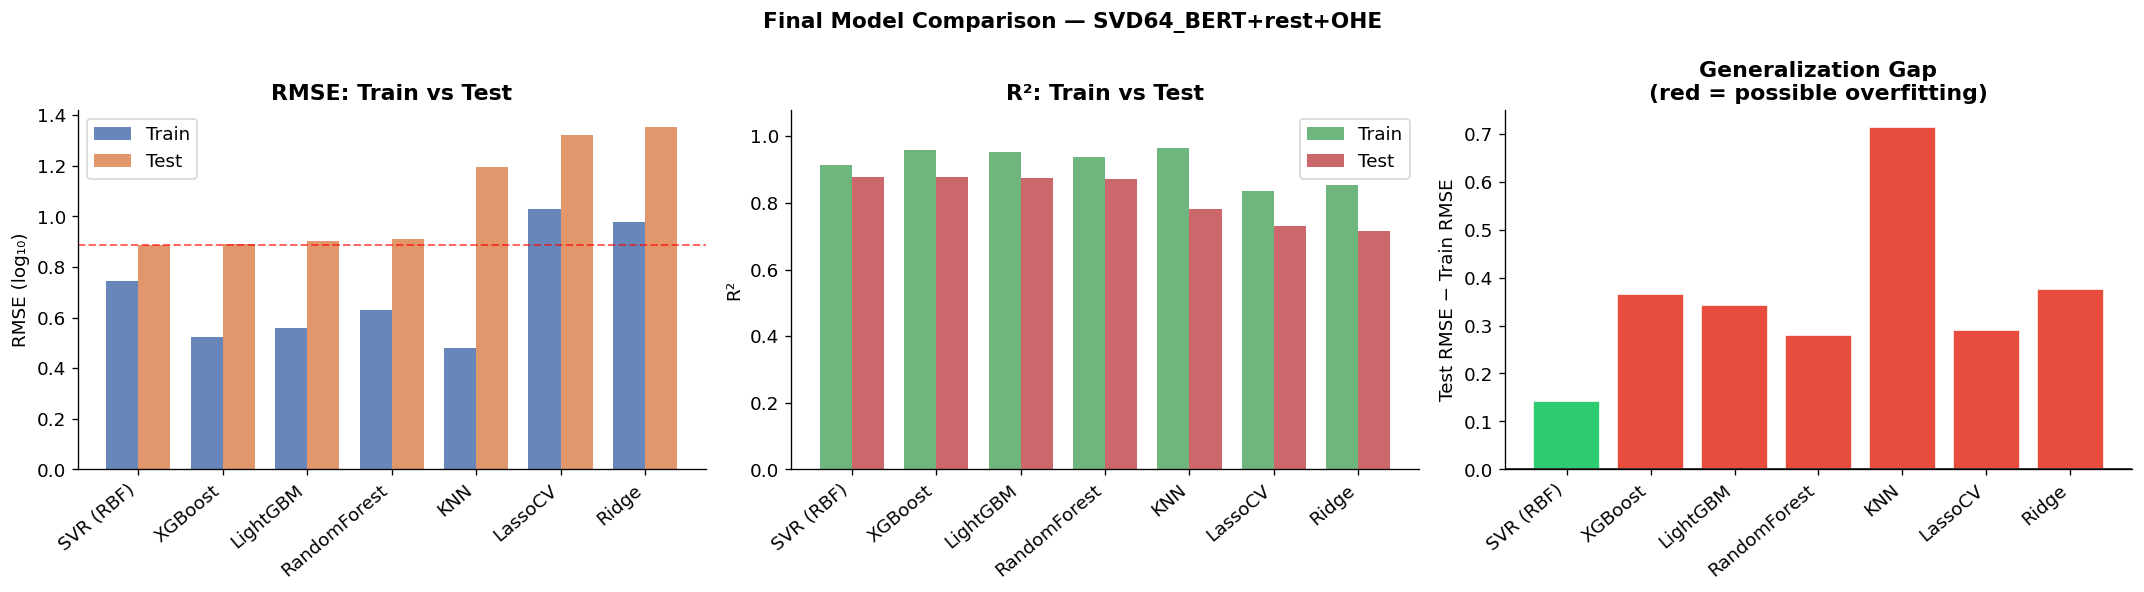

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x, w = np.arange(len(results_df)), 0.38

axes[0].bar(x - w/2, results_df['Train RMSE'], w, label='Train', color='#4C72B0', alpha=0.85)
axes[0].bar(x + w/2, results_df['Test RMSE'],  w, label='Test',  color='#DD8452', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(results_df['Model'], rotation=40, ha='right')
axes[0].set_ylabel('RMSE (log₁₀)'); axes[0].set_title('RMSE: Train vs Test', fontweight='bold')
axes[0].legend(); axes[0].axhline(results_df['Test RMSE'].min(), color='red', lw=1.2, ls='--', alpha=0.6)

axes[1].bar(x - w/2, results_df['Train R²'], w, label='Train', color='#55A868', alpha=0.85)
axes[1].bar(x + w/2, results_df['Test R²'],  w, label='Test',  color='#C44E52', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(results_df['Model'], rotation=40, ha='right')
axes[1].set_ylabel('R²'); axes[1].set_title('R²: Train vs Test', fontweight='bold')
axes[1].set_ylim(0, 1.08); axes[1].legend()

gap    = results_df['Test RMSE'] - results_df['Train RMSE']
g_clrs = ['#e74c3c' if g > 0.15 else '#2ecc71' for g in gap]
axes[2].bar(x, gap, color=g_clrs, edgecolor='white')
axes[2].set_xticks(x); axes[2].set_xticklabels(results_df['Model'], rotation=40, ha='right')
axes[2].axhline(0, color='black', lw=0.9)
axes[2].set_ylabel('Test RMSE − Train RMSE')
axes[2].set_title('Generalization Gap\n(red = possible overfitting)', fontweight='bold')

plt.suptitle(f'Final Model Comparison — {BEST_REPR}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

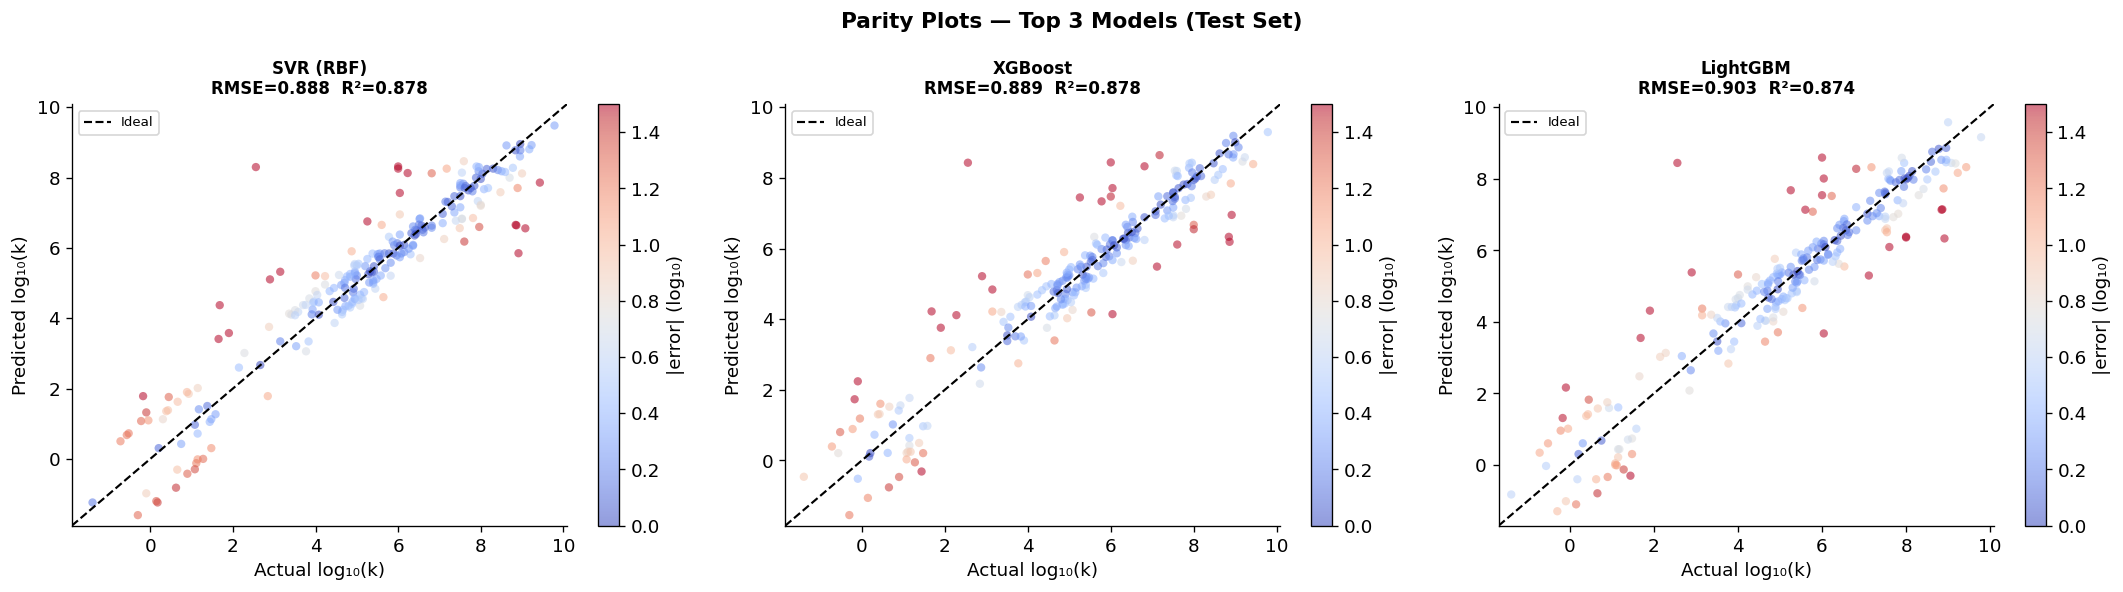

In [24]:
top3 = results_df.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, mname in zip(axes, top3):
    m, ns = fitted_models[mname]
    Xte_use = Xte_scaled if ns else Xte_active
    pte = m.predict(Xte_use)
    row = results_df[results_df['Model'] == mname].iloc[0]
    sc = ax.scatter(y_test, pte, c=np.abs(y_test - pte),
                    cmap='coolwarm', alpha=0.55, s=25, edgecolors='none', vmin=0, vmax=1.5)
    plt.colorbar(sc, ax=ax, label='|error| (log₁₀)')
    lo, hi = min(y_test.min(), pte.min()) - 0.3, max(y_test.max(), pte.max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.3, label='Ideal')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual log₁₀(k)'); ax.set_ylabel('Predicted log₁₀(k)')
    ax.set_title(f'{mname}\nRMSE={row["Test RMSE"]:.3f}  R²={row["Test R²"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Parity Plots — Top 3 Models (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Per-Radical Group Evaluation

One global model trained on all data (OHE Radical Name as input feature).  
Metrics computed separately for each radical group on the held-out test set.

In [25]:
BEST_MODEL_NAME = results_df.iloc[0]['Model']
best_model, needs_scale = fitted_models[BEST_MODEL_NAME]
Xte_best  = Xte_scaled if needs_scale else Xte_active
pte_best  = best_model.predict(Xte_best)
radical_test = df_model[RADICAL_COL].values[idx_te]

radical_rows = []
for rad in sorted(df_model[RADICAL_COL].unique()):
    mask = radical_test == rad
    if mask.sum() < 3:
        continue
    yt, yp = y_test[mask], pte_best[mask]
    radical_rows.append({
        'Radical':  rad,
        'N_test':   int(mask.sum()),
        'RMSE':     round(rmse(yt, yp), 4),
        'MAE':      round(float(mean_absolute_error(yt, yp)), 4),
        'R²':       round(float(r2_score(yt, yp)), 4) if len(yt) > 1 else np.nan,
    })

radical_eval_df = pd.DataFrame(radical_rows).sort_values('RMSE').reset_index(drop=True)
print(f'Per-Radical Evaluation — {BEST_MODEL_NAME}  |  {BEST_REPR}')
display(radical_eval_df.style
    .background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²'],          cmap='RdYlGn')
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}'}))

Per-Radical Evaluation — SVR (RBF)  |  SVD64_BERT+rest+OHE


,Radical,N_test,RMSE,MAE,R²
0,RO2*,86,0.7947,0.5226,0.8867
1,tert-RO2*,69,0.8703,0.6798,0.8389
2,sec-RO2*,87,0.9850,0.6506,0.8426


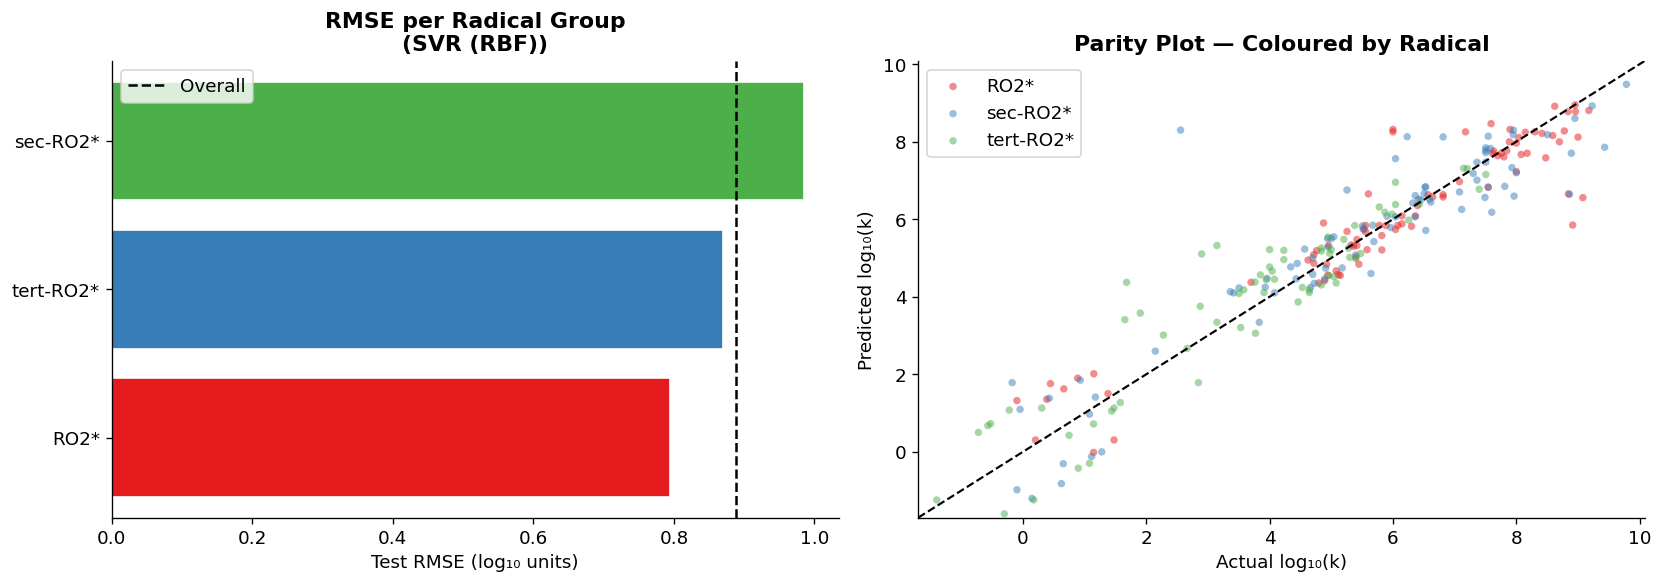

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_r = sns.color_palette('Set1', len(radical_eval_df))
axes[0].barh(radical_eval_df['Radical'], radical_eval_df['RMSE'],
             color=palette_r, edgecolor='white')
axes[0].set_xlabel('Test RMSE (log₁₀ units)')
axes[0].set_title(f'RMSE per Radical Group\n({BEST_MODEL_NAME})', fontweight='bold')
axes[0].axvline(results_df.iloc[0]['Test RMSE'], color='black', ls='--', lw=1.5, label='Overall')
axes[0].legend()

parity_palette = sns.color_palette('Set1', df_model[RADICAL_COL].nunique())
for i, rad in enumerate(sorted(df_model[RADICAL_COL].unique())):
    mask = radical_test == rad
    axes[1].scatter(y_test[mask], pte_best[mask],
                    alpha=0.5, s=20, color=parity_palette[i], label=rad, edgecolors='none')
lo, hi = y_test.min() - 0.3, y_test.max() + 0.3
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1.3)
axes[1].set_xlim(lo, hi); axes[1].set_ylim(lo, hi)
axes[1].set_xlabel('Actual log₁₀(k)'); axes[1].set_ylabel('Predicted log₁₀(k)')
axes[1].set_title('Parity Plot — Coloured by Radical', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

Feature names OK: 321 features
Computing SHAP (SVR (RBF))...


  0%|          | 0/242 [00:00<?, ?it/s]

  0%|          | 1/242 [00:05<23:31,  5.86s/it]

  1%|          | 2/242 [00:11<22:32,  5.63s/it]

  1%|          | 3/242 [00:16<21:48,  5.47s/it]

...

 99%|█████████▉| 240/242 [24:29<00:05,  2.54s/it]

100%|█████████▉| 241/242 [24:32<00:02,  2.59s/it]

100%|██████████| 242/242 [24:34<00:00,  2.59s/it]

100%|██████████| 242/242 [24:34<00:00,  6.09s/it]

  (KernelSHAP approximate)
Done.


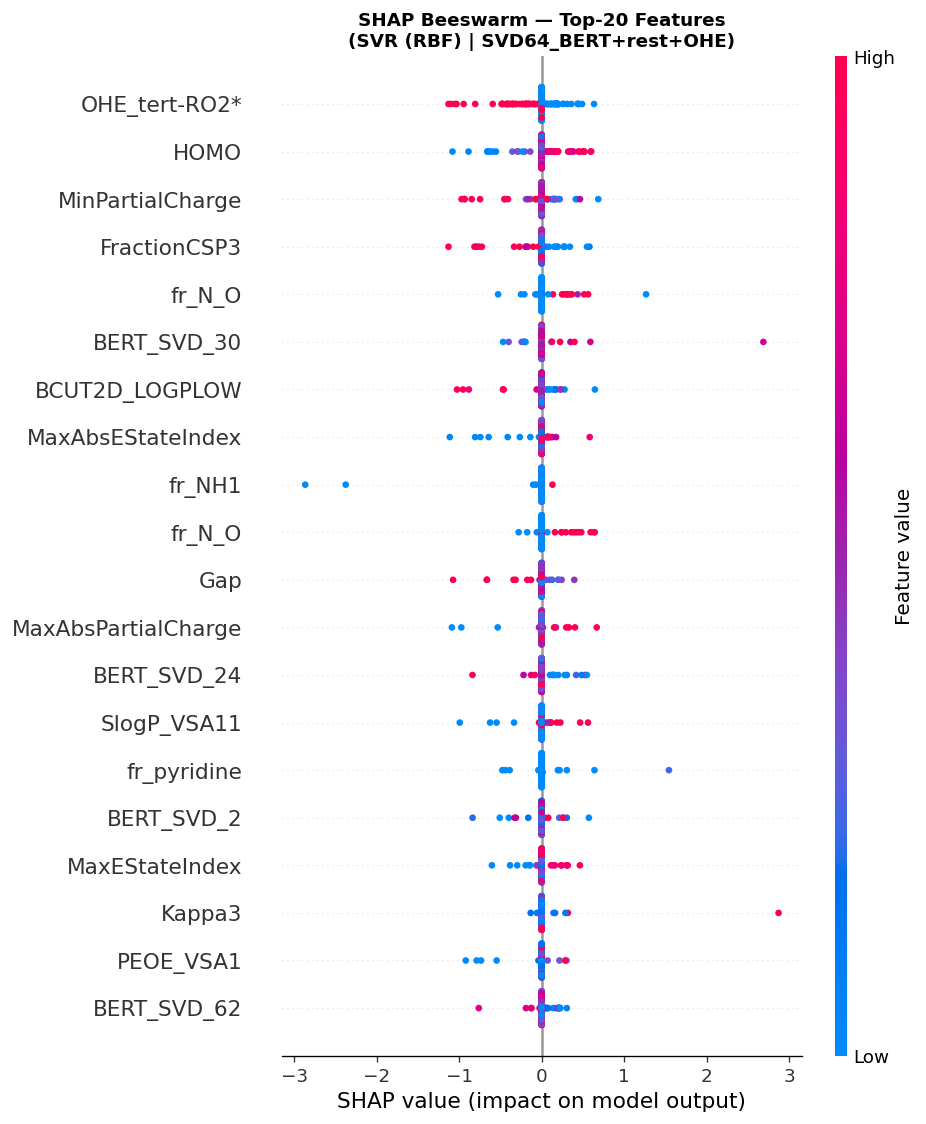

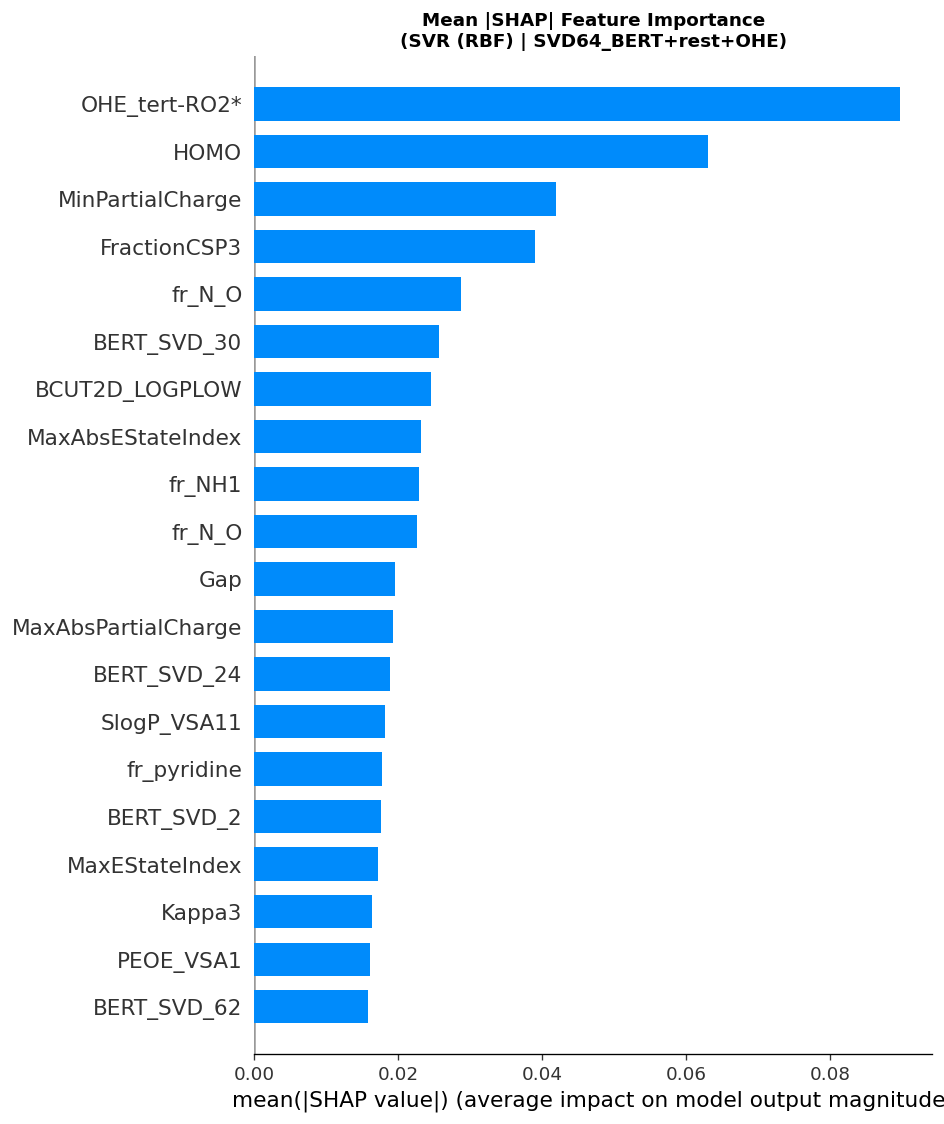

Top-20 features by mean |SHAP|:


,Feature,Mean_AbsSHAP
0,OHE_tert-RO2*,0.089727
1,HOMO,0.063085
2,MinPartialCharge,0.041948
3,FractionCSP3,0.039084
4,fr_N_O,0.028771
5,BERT_SVD_30,0.025710
6,BCUT2D_LOGPLOW,0.024612
7,MaxAbsEStateIndex,0.023235
8,fr_NH1,0.022904
9,fr_N_O,0.022670


In [27]:
# ── 8. SHAP Feature Importance ───────────────────────────────────────────────
try:
    import shap
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

# Build meaningful feature names for the best representation
cfg      = DR_CONFIGS[BEST_REPR]
_method  = cfg['method']
_n       = cfg['n']
_dr_blk  = cfg['dr_block']
_raw_app = cfg['raw_append']

def _tok_names(tok):
    if tok == 'bert':
        if _method == 'svd' and _dr_blk == 'bert':
            return [f'BERT_SVD_{i}'  for i in range(_n)]
        if _method == 'pca' and _dr_blk == 'bert':
            return [f'BERT_PCA_{i}'  for i in range(_n)]
        return [f'BERT_{i}' for i in range(768)] if X_bert is not None else []
    if tok == 'calcdesc': return list(calcdesc_names_kept)
    if tok == 'qm':       return ['HOMO', 'LUMO', 'Gap']
    if tok == 'ohe':      return [f'OHE_{c}' for c in ohe_enc.categories_[0][1:]]
    return []

if _method in ('svd', 'pca') and '+' not in _dr_blk:
    shap_names = _tok_names(_dr_blk)
else:
    shap_names = sum([_tok_names(t.strip()) for t in _dr_blk.split('+')], [])
shap_names += sum([_tok_names(t.strip()) for t in _raw_app.split('+') if t.strip()], [])

if len(shap_names) != Xte_best.shape[1]:
    print(f'Name count mismatch ({len(shap_names)} vs {Xte_best.shape[1]}) — using generic names')
    shap_names = [f'Feat_{i}' for i in range(Xte_best.shape[1])]
else:
    print(f'Feature names OK: {len(shap_names)} features')

print(f'Computing SHAP ({BEST_MODEL_NAME})...')
if BEST_MODEL_NAME in ('XGBoost', 'LightGBM', 'RandomForest'):
    explainer = shap.TreeExplainer(best_model)
    shap_vals = explainer.shap_values(Xte_best)
else:
    bg = shap.sample(Xtr_active if not needs_scale else Xtr_scaled,
                     min(100, len(y_train)), random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(best_model.predict, bg)
    shap_vals = explainer.shap_values(Xte_best, nsamples=100)
    print('  (KernelSHAP approximate)')
print('Done.')

# Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, Xte_best, feature_names=shap_names, max_display=20, show=False)
plt.title(f'SHAP Beeswarm — Top-20 Features\n({BEST_MODEL_NAME} | {BEST_REPR})',
          fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Bar (mean |SHAP|)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals, Xte_best, feature_names=shap_names,
                  plot_type='bar', max_display=20, show=False)
plt.title(f'Mean |SHAP| Feature Importance\n({BEST_MODEL_NAME} | {BEST_REPR})',
          fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

shap_importance_df = (
    pd.DataFrame({'Feature': shap_names, 'Mean_AbsSHAP': np.abs(shap_vals).mean(axis=0)})
    .sort_values('Mean_AbsSHAP', ascending=False).reset_index(drop=True)
)
print('Top-20 features by mean |SHAP|:')
display(shap_importance_df.head(20))

In [28]:
# ── 9. Global Model vs Per-Radical-Group Separate Models ─────────────────────
# Train one XGBoost per radical group; compare test RMSE/R² vs global model.
print(f'Global model: {BEST_MODEL_NAME}  |  {BEST_REPR}\n')

Xtr_pg = feature_sets[BEST_REPR]['Xtr']
Xte_pg = feature_sets[BEST_REPR]['Xte']
radical_tr_labels = df_model[RADICAL_COL].values[idx_tr]
radical_te_labels = df_model[RADICAL_COL].values[idx_te]

comparison_rows = []
for rad in sorted(df_model[RADICAL_COL].unique()):
    mask_tr = radical_tr_labels == rad
    mask_te = radical_te_labels == rad

    yte        = y_test[mask_te]
    yp_global  = pte_best[mask_te]
    rmse_glob  = rmse(yte, yp_global)
    r2_glob    = float(r2_score(yte, yp_global)) if len(yte) > 1 else np.nan

    if mask_tr.sum() < 20:
        comparison_rows.append({'Radical': rad,
            'N_train': int(mask_tr.sum()), 'N_test': int(mask_te.sum()),
            'Global RMSE': round(rmse_glob, 4), 'Group RMSE': np.nan,
            'Global R²': round(r2_glob, 4),     'Group R²':  np.nan,
            'ΔRMSE': np.nan, 'Verdict': 'Global only (too few train samples)'})
        continue

    m_g = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=RANDOM_STATE, verbosity=0)
    m_g.fit(Xtr_pg[mask_tr], y_train[mask_tr])
    yp_group  = m_g.predict(Xte_pg[mask_te])
    rmse_grp  = rmse(yte, yp_group)
    r2_grp    = float(r2_score(yte, yp_group)) if len(yte) > 1 else np.nan
    delta     = rmse_glob - rmse_grp           # positive → group model better
    verdict   = 'Group better ✓' if delta > 0 else 'Global better'

    comparison_rows.append({'Radical': rad,
        'N_train': int(mask_tr.sum()), 'N_test': int(mask_te.sum()),
        'Global RMSE': round(rmse_glob, 4), 'Group RMSE': round(rmse_grp, 4),
        'Global R²':   round(r2_glob, 4),   'Group R²':   round(r2_grp, 4),
        'ΔRMSE': round(delta, 4), 'Verdict': verdict})
    print(f'{rad:12s}: Global RMSE={rmse_glob:.4f} R²={r2_glob:.4f}  |  '
          f'Group RMSE={rmse_grp:.4f} R²={r2_grp:.4f}  →  {verdict}')

comparison_df = pd.DataFrame(comparison_rows)
fmt_cols = {c: '{:.4f}' for c in ['Global RMSE', 'Group RMSE', 'Global R²', 'Group R²', 'ΔRMSE']
            if c in comparison_df.columns}
display(comparison_df.style
    .background_gradient(subset=['Global RMSE', 'Group RMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Global R²',   'Group R²'],   cmap='RdYlGn')
    .format(fmt_cols, na_rep='N/A'))

Global model: SVR (RBF)  |  SVD64_BERT+rest+OHE



RO2*        : Global RMSE=0.7947 R²=0.8867  |  Group RMSE=1.2276 R²=0.7297  →  Global better


sec-RO2*    : Global RMSE=0.9850 R²=0.8426  |  Group RMSE=1.3347 R²=0.7110  →  Global better


tert-RO2*   : Global RMSE=0.8703 R²=0.8389  |  Group RMSE=0.9407 R²=0.8118  →  Global better


,Radical,N_train,N_test,Global RMSE,Group RMSE,Global R²,Group R²,ΔRMSE,Verdict
0,RO2*,344,86,0.7947,1.2276,0.8867,0.7297,-0.4328,Global better
1,sec-RO2*,345,87,0.9850,1.3347,0.8426,0.7110,-0.3497,Global better
2,tert-RO2*,275,69,0.8703,0.9407,0.8389,0.8118,-0.0704,Global better


---
## 9. Residual Analysis

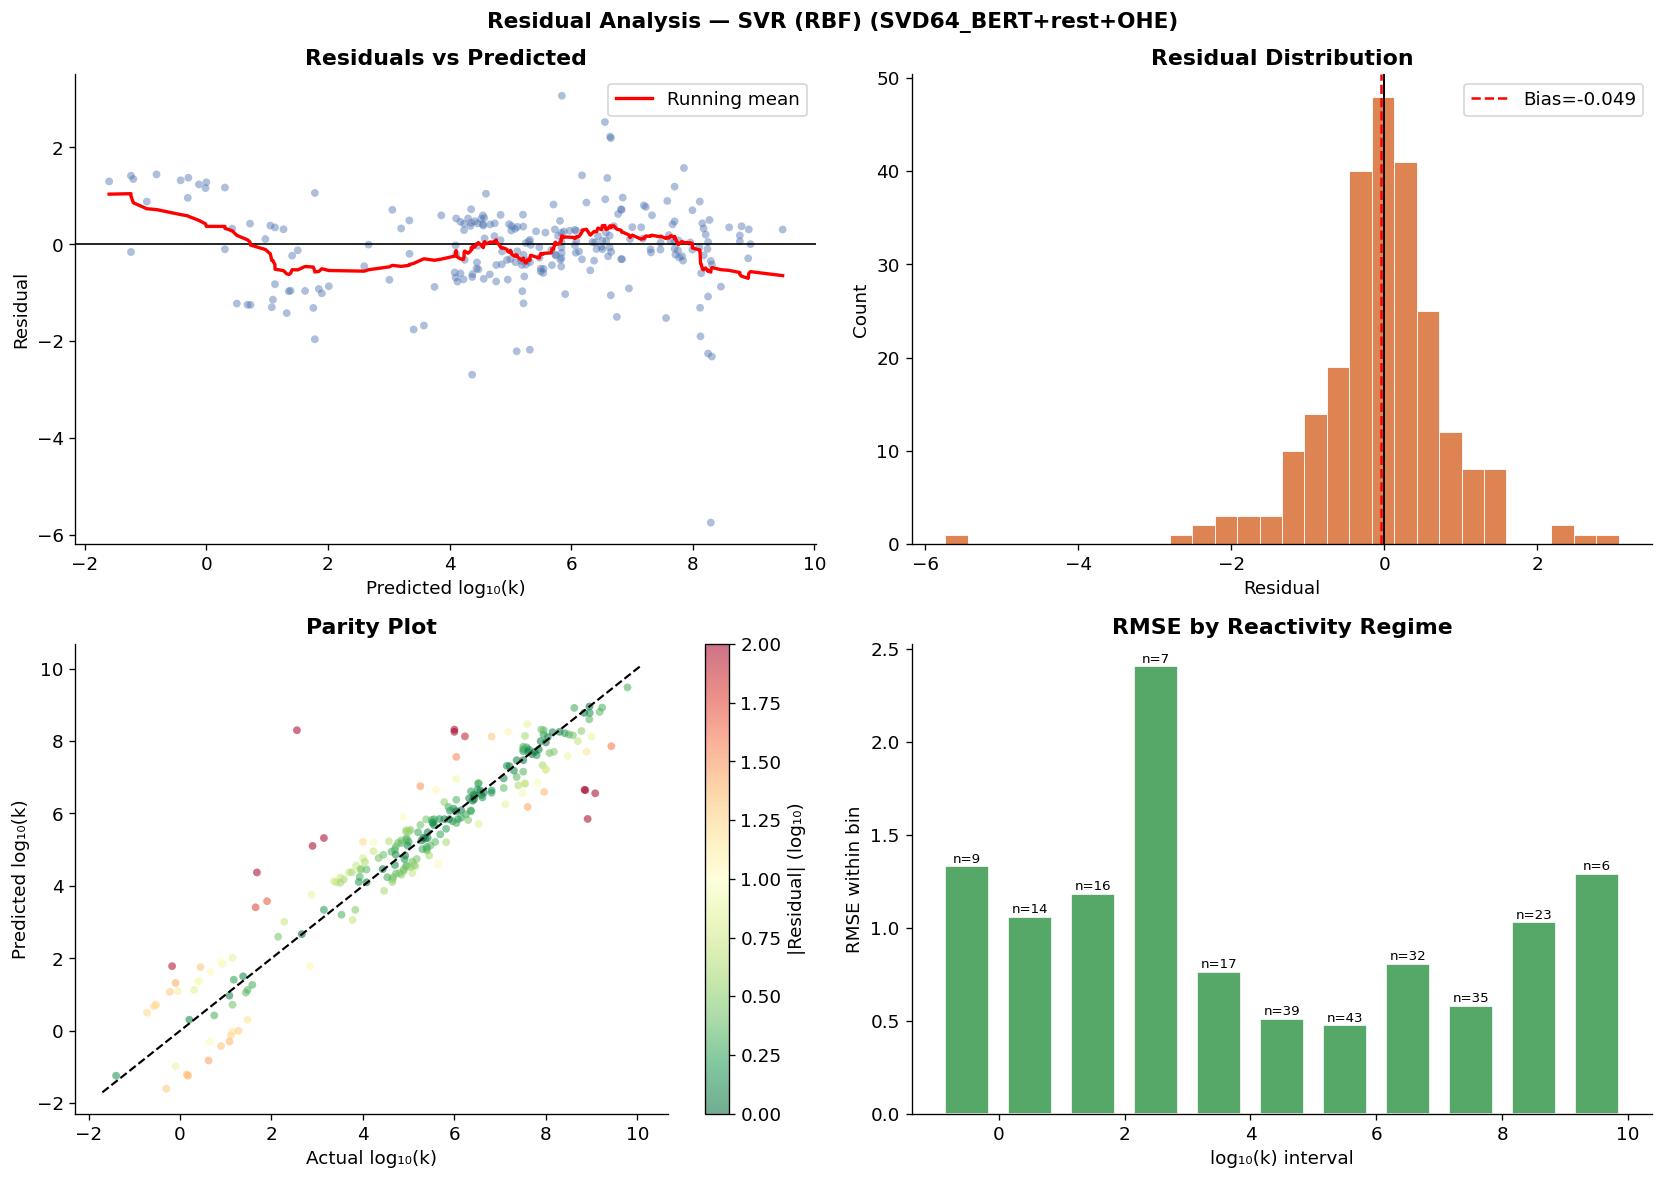

Systematic bias   : -0.0489 log₁₀
RMSE              : 0.8884 log₁₀
Max |error|       : 5.741 log₁₀
% off > 1 log₁₀   : 18.6%


In [29]:
Xtr_best = Xtr_scaled if needs_scale else Xtr_active
ptr_best = best_model.predict(Xtr_best)
resid = y_test - pte_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(pte_best, resid, alpha=0.45, s=22, color='#4C72B0', edgecolors='none')
axes[0, 0].axhline(0, color='black', lw=1)
sort_i = np.argsort(pte_best)
rm = pd.Series(resid[sort_i]).rolling(25, center=True, min_periods=5).mean()
axes[0, 0].plot(pte_best[sort_i], rm.values, color='red', lw=2, label='Running mean')
axes[0, 0].set_xlabel('Predicted log₁₀(k)'); axes[0, 0].set_ylabel('Residual')
axes[0, 0].set_title('Residuals vs Predicted', fontweight='bold'); axes[0, 0].legend()

axes[0, 1].hist(resid, bins=30, color='#DD8452', edgecolor='white', lw=0.5)
axes[0, 1].axvline(0, color='black', lw=1.2)
axes[0, 1].axvline(resid.mean(), color='red', lw=1.5, ls='--', label=f'Bias={resid.mean():.3f}')
axes[0, 1].set_xlabel('Residual'); axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Residual Distribution', fontweight='bold'); axes[0, 1].legend()

sc = axes[1, 0].scatter(y_test, pte_best, c=np.abs(resid), cmap='RdYlGn_r',
                         alpha=0.55, s=22, edgecolors='none', vmin=0, vmax=2)
plt.colorbar(sc, ax=axes[1, 0], label='|Residual| (log₁₀)')
lo, hi = y_test.min() - 0.3, y_test.max() + 0.3
axes[1, 0].plot([lo, hi], [lo, hi], 'k--', lw=1.3)
axes[1, 0].set_xlabel('Actual log₁₀(k)'); axes[1, 0].set_ylabel('Predicted log₁₀(k)')
axes[1, 0].set_title('Parity Plot', fontweight='bold')

bins_e  = np.arange(np.floor(y_test.min()), np.ceil(y_test.max()) + 1)
bin_ids = np.digitize(y_test, bins_e)
b_rmse, b_center, b_cnt = [], [], []
for b in range(1, len(bins_e)):
    mask_b = bin_ids == b
    if mask_b.sum() >= 4:
        b_rmse.append(rmse(y_test[mask_b], pte_best[mask_b]))
        b_center.append(0.5 * (bins_e[b-1] + bins_e[b]))
        b_cnt.append(int(mask_b.sum()))
bars2 = axes[1, 1].bar(b_center, b_rmse, width=0.7, color='#55A868', edgecolor='white')
for rect, cnt in zip(bars2, b_cnt):
    axes[1, 1].text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.005,
                    f'n={cnt}', ha='center', va='bottom', fontsize=8)
axes[1, 1].set_xlabel('log₁₀(k) interval'); axes[1, 1].set_ylabel('RMSE within bin')
axes[1, 1].set_title('RMSE by Reactivity Regime', fontweight='bold')

plt.suptitle(f'Residual Analysis — {BEST_MODEL_NAME} ({BEST_REPR})',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Systematic bias   : {resid.mean():+.4f} log₁₀')
print(f'RMSE              : {rmse(y_test, pte_best):.4f} log₁₀')
print(f'Max |error|       : {np.abs(resid).max():.3f} log₁₀')
print(f'% off > 1 log₁₀   : {(np.abs(resid)>1.0).mean()*100:.1f}%')

In [30]:
results_df.to_csv('final_model_results_bert.csv', index=False)
bench_df.to_csv('dr_benchmark_bert.csv', index=False)
summary_df.to_csv('dr_selection_summary_bert.csv', index=False)
radical_eval_df.to_csv('per_radical_evaluation_bert.csv', index=False)
shap_importance_df.to_csv('shap_importance_bert.csv', index=False)
comparison_df.to_csv('per_radical_group_models_bert.csv', index=False)

print('Saved:')
print('  final_model_results_bert.csv')
print('  dr_benchmark_bert.csv')
print('  dr_selection_summary_bert.csv')
print('  per_radical_evaluation_bert.csv')
print('  shap_importance_bert.csv')
print('  per_radical_group_models_bert.csv')

Saved:
  final_model_results_bert.csv
  dr_benchmark_bert.csv
  dr_selection_summary_bert.csv
  per_radical_evaluation_bert.csv
  shap_importance_bert.csv
  per_radical_group_models_bert.csv


In [31]:
# ── Save Trained Pipeline (for use in Notebook 3) ────────────────────────────
import joblib

cfg_best = DR_CONFIGS[BEST_REPR]
dr_transformer = None
dr_pca_scaler  = None

# Refit DR transformer (was built inside apply_dr; refitting is deterministic)
if cfg_best['method'] in ('svd', 'pca') and '+' not in cfg_best['dr_block']:
    dr_input_tr = FEAT_LOOKUP[cfg_best['dr_block']][0]  # training-only input
    if cfg_best['method'] == 'svd':
        dr_transformer = TruncatedSVD(n_components=safe_n(cfg_best['n'], dr_input_tr),
                                       random_state=RANDOM_STATE)
        dr_transformer.fit(dr_input_tr)
    else:
        dr_pca_scaler = StandardScaler()
        dr_input_s    = dr_pca_scaler.fit_transform(dr_input_tr)
        dr_transformer = PCA(n_components=safe_n(cfg_best['n'], dr_input_s),
                              random_state=RANDOM_STATE)
        dr_transformer.fit(dr_input_s)

radical_pipeline = {
    # Model
    'best_model'      : best_model,
    'best_model_name' : BEST_MODEL_NAME,
    'needs_scale'     : needs_scale,
    'sc_final'        : sc_final,
    # Categorical encoding
    'ohe_enc'         : ohe_enc,
    'radical_col'     : RADICAL_COL,
    'radical_cats'    : ohe_enc.categories_[0].tolist(),
    # Feature scalers (fitted on train only)
    'sc_bert'         : sc_bert,
    'sc_calc'         : sc_calc,
    'sc_qm'           : sc_qm,
    # CalcDesc+Fragments preprocessing
    'imputer_calcdesc': imputer,
    'col_mask'        : col_mask,
    'calcdesc_names'  : calcdesc_names_kept,
    # QM imputer
    'qm_imputer'      : qm_imp,
    # DR settings
    'best_repr'       : BEST_REPR,
    'dr_config'       : cfg_best,
    'dr_transformer'  : dr_transformer,
    'dr_pca_scaler'   : dr_pca_scaler,
    # BERT settings (for computing embeddings of new molecules)
    'bert_model_id'   : BERT_MODEL_ID,
    'bert_cache'      : BERT_CACHE,
    # Performance summary
    'test_r2'         : float(results_df.iloc[0]['Test R²']),
    'test_rmse'       : float(results_df.iloc[0]['Test RMSE']),
}

joblib.dump(radical_pipeline, 'radical_pipeline.pkl')
print('radical_pipeline.pkl saved successfully.')
print(f'  Model      : {BEST_MODEL_NAME}  (needs_scale={needs_scale})')
print(f'  Feature set: {BEST_REPR}')
print(f'  DR method  : {cfg_best["method"]}  /  transformer: {type(dr_transformer).__name__ if dr_transformer else "None"}')
print(f'  Test R²    : {results_df.iloc[0]["Test R²"]:.4f}')
print(f'  Test RMSE  : {results_df.iloc[0]["Test RMSE"]:.4f}')

radical_pipeline.pkl saved successfully.
  Model      : SVR (RBF)  (needs_scale=True)
  Feature set: SVD64_BERT+rest+OHE
  DR method  : svd  /  transformer: TruncatedSVD
  Test R²    : 0.8782
  Test RMSE  : 0.8884


---
## 11. Conclusions

### Reviewer Comments Addressed

| Reviewer Point | How Addressed |
|---|---|
| #1 — Look at each radical group separately | Sections 8–9: per-radical RMSE/R²; global vs per-group model comparison |
| #2 — Encode radical as input feature (not separate models) | OHE `Radical Name` appended to all feature combos; one global model |
| #3 — More descriptors (CalcMolDescriptors, SMILES-BERT) | Sections 3.1 & 3.2 |
| #4 — Low HOMO/LUMO correlation alone is insufficient | HOMO/LUMO/Gap retained but combined with richer structural features |
| #5 — Compare descriptor combinations | Section 5: 15 representations × 3 benchmark models → heatmap |

### Feature Types

| Feature | Dims | Role |
|---|---|---|
| SMILES-BERT (ChemBERTa) | 768 | Main structural representation |
| CalcMolDescriptors | ~217 | Physicochemical properties |
| Fragments (fr_*) | ~85 | Functional-group counts |
| HOMO/LUMO/Gap | 3 | Electronic structure (GFN2-xTB) |
| OHE Radical | n_rad−1 | Mechanism-level reactivity shift |

### Key Findings
- One global model with OHE Radical captures cross-group patterns and typically outperforms separate per-group models
- SHAP reveals which structural descriptors and BERT components most influence log₁₀(k)
- StratifiedKFold by radical group gives unbiased CV estimates across all three reactivity classes
- DR benchmark identifies the optimal compression before final model training